# Water Quality — Exploratory Data Analysis
This notebook performs exploratory data analysis (EDA) on water quality measurements. 

In [6]:
# Standard imports for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import warnings
warnings.filterwarnings("ignore")

## Load data
Read the source Excel file into a DataFrame for analysis.

In [8]:
# Load the dataset
df = pd.read_excel('data/WQD.xlsx')

In [9]:
# Quick peek at the data
df.head()

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


In [10]:
# Column names
df.columns

Index(['Temp', 'Turbidity (cm)', 'DO(mg/L)', 'BOD (mg/L)', 'CO2', 'pH`',
       'Alkalinity (mg L-1 )', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )',
       'Ammonia (mg L-1 )', 'Nitrite (mg L-1 )', 'Phosphorus (mg L-1 )',
       'H2S (mg L-1 )', 'Plankton (No. L-1)', 'Water Quality'],
      dtype='object')

In [11]:
# Check missing values
df.isnull().sum()

Temp                    0
Turbidity (cm)          0
DO(mg/L)                0
BOD (mg/L)              0
CO2                     0
pH`                     0
Alkalinity (mg L-1 )    0
Hardness (mg L-1 )      0
Calcium (mg L-1 )       0
Ammonia (mg L-1 )       0
Nitrite (mg L-1 )       0
Phosphorus (mg L-1 )    0
H2S (mg L-1 )           0
Plankton (No. L-1)      0
Water Quality           0
dtype: int64

In [12]:
# Summary statistics for numeric columns
df.describe()

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,25.695663,39.046681,5.300346,3.125079,6.375929,7.713468,93.717183,127.055476,84.871932,0.048269,0.642948,1.172749,0.016473,3805.510620,1.023256
std,9.670202,20.942726,1.832736,2.292060,2.831104,1.580282,68.949048,78.883091,75.718842,0.122886,0.903592,1.082648,0.011874,1208.547783,0.820996
min,0.194046,0.051424,0.133928,1.000621,0.001155,0.003944,25.012328,0.255805,0.018293,0.000001,0.000025,0.000128,0.000002,78.603733,0.000000
25%,19.775926,22.224140,3.978366,1.522077,5.048761,6.443019,40.422364,69.479620,23.745078,0.012750,0.010636,0.028355,0.010072,2956.020049,0.000000
50%,25.041849,30.205696,5.000754,2.236022,6.598076,7.743176,67.562607,111.063301,62.845419,0.026335,0.099908,0.975312,0.019049,3729.396476,1.000000
75%,30.277718,55.945735,6.521225,4.324578,8.241532,9.035251,132.834386,162.675648,115.596833,0.039016,1.166714,2.101317,0.019567,4555.089727,2.000000
max,84.251522,99.797743,14.970122,14.943006,14.984216,14.851195,299.913160,398.796550,399.321398,0.999300,4.989535,4.974457,0.099220,7460.415789,2.000000


## Target mapping
The dataset encodes water quality as integers: 0 = Excellent, 1 = Good, 2 = Poor. We create a human-readable label column.

In [13]:
# Map numeric classes to readable labels
label_map = {0: 'Excellent', 1: 'Good', 2: 'Poor'}
df['Water_Label'] = df['Water Quality'].map(label_map)

<Axes: xlabel='Water_Label', ylabel='count'>

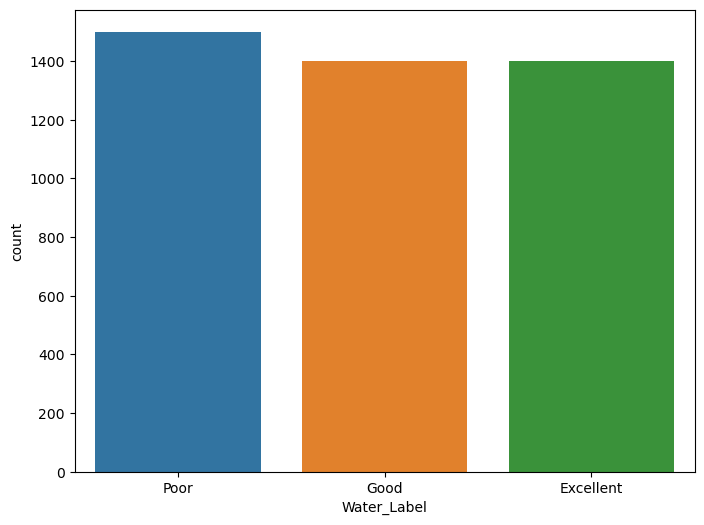

In [14]:
# Class distribution
df['Water Quality'].value_counts()
plt.figure(figsize=(8, 6))
sns.countplot(x='Water_Label', data=df)

In [15]:
# Count duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Univariate distributions
Plot histograms and KDEs for numeric features to inspect their distributions.

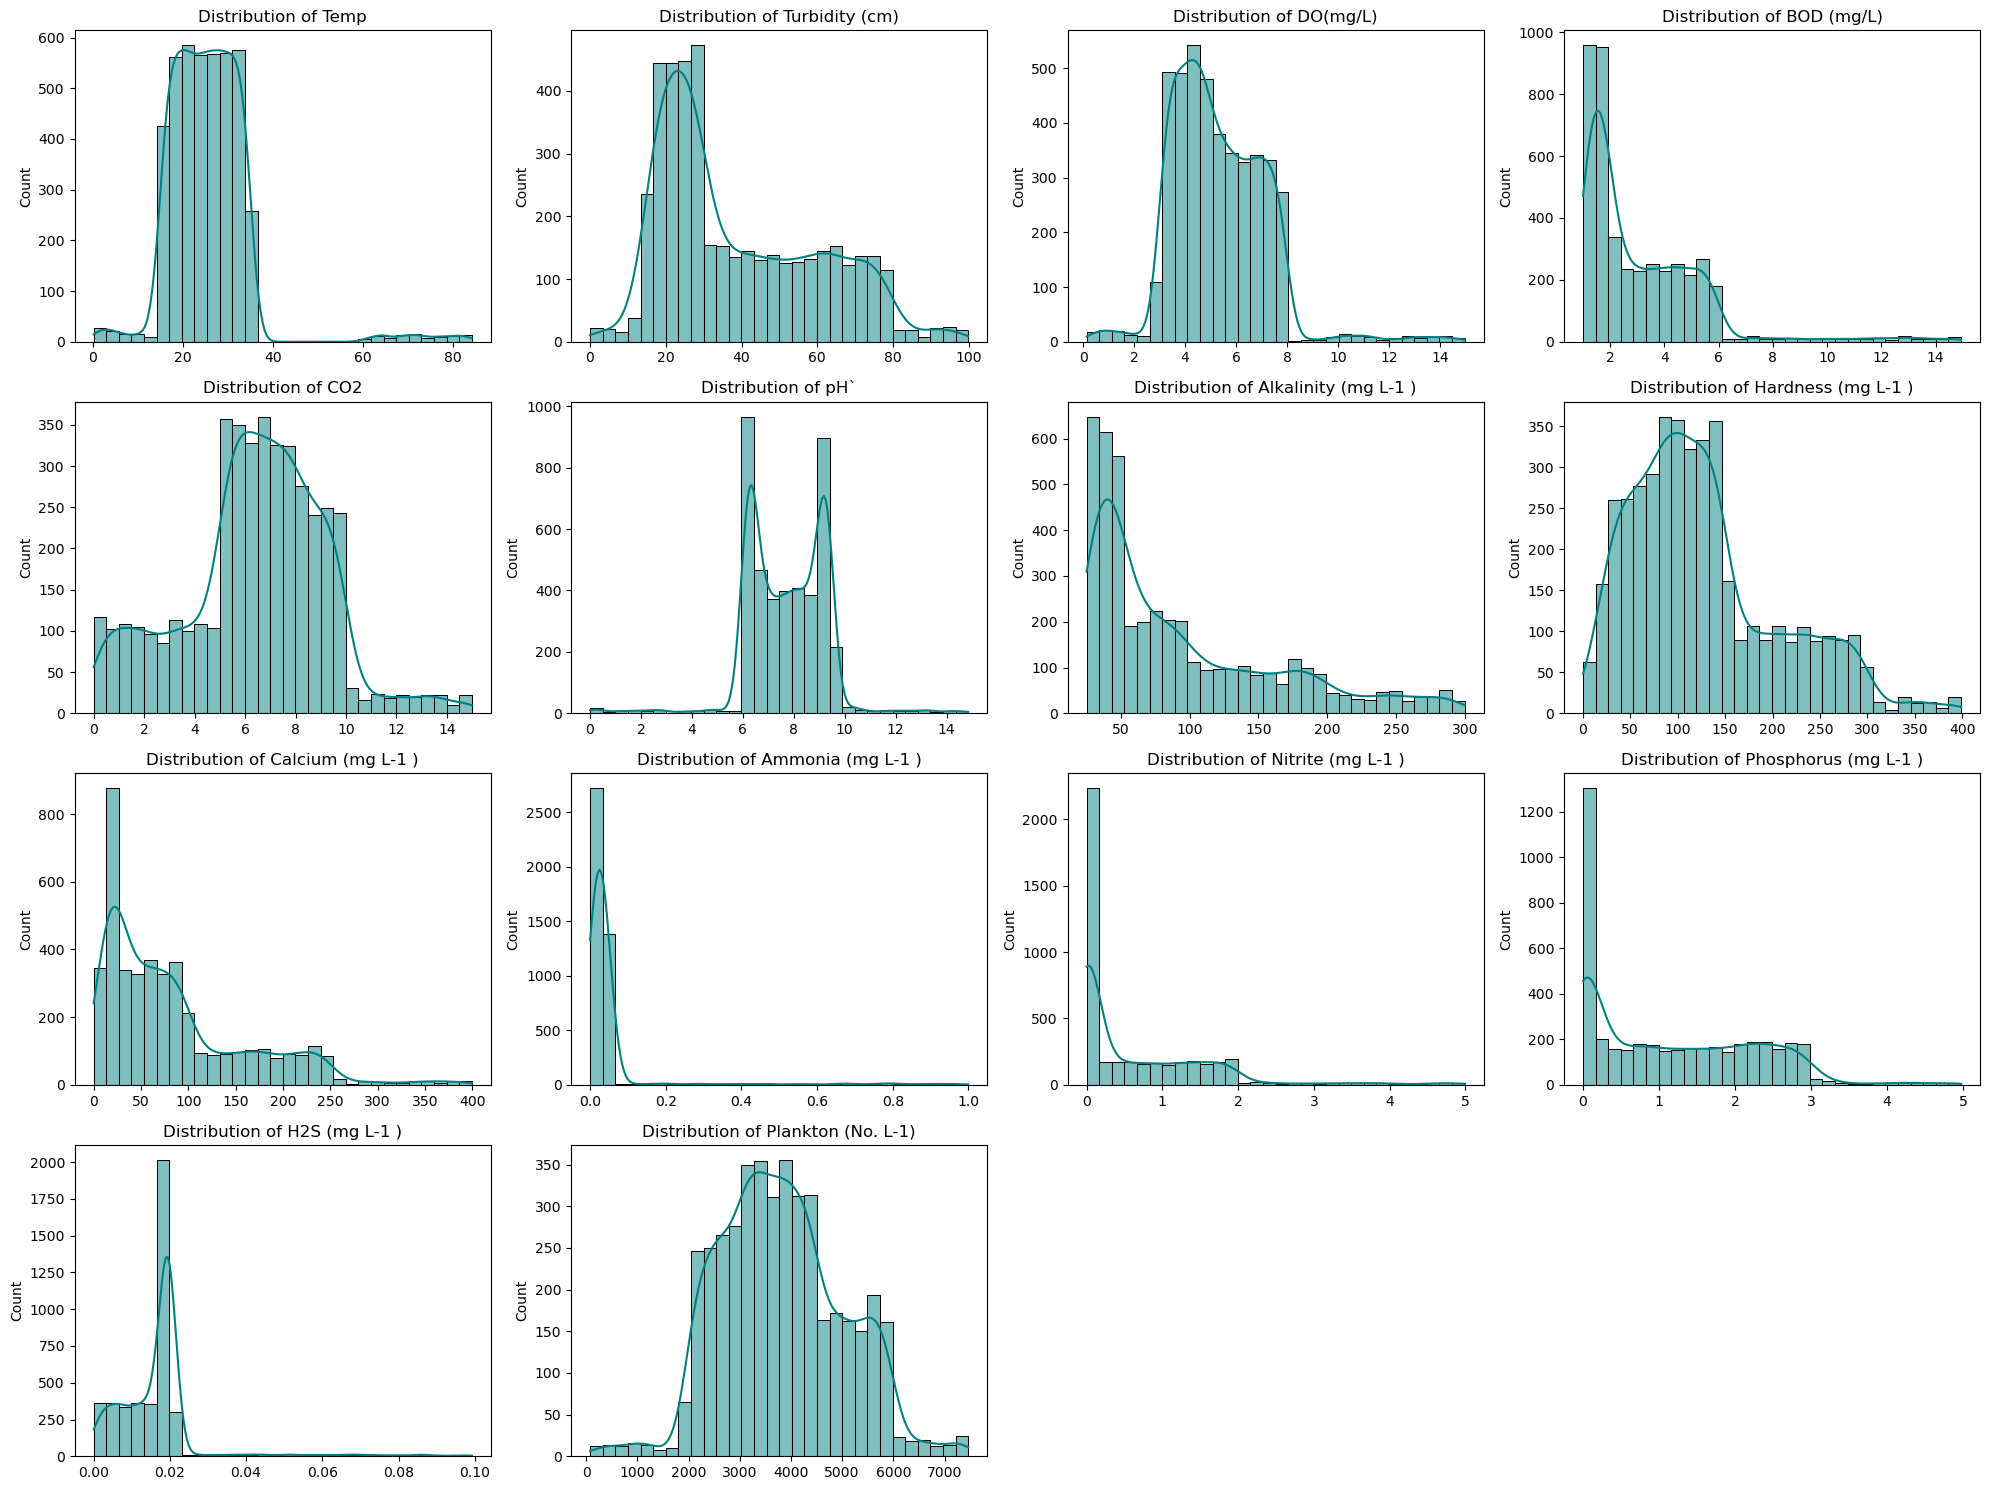

In [16]:
# Define feature columns (exclude target and label)
feature_columns = df.columns.drop(['Water Quality', 'Water_Label'])

# Histograms with KDE
plt.figure(figsize=(20, 15))
for i, col in enumerate(feature_columns):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

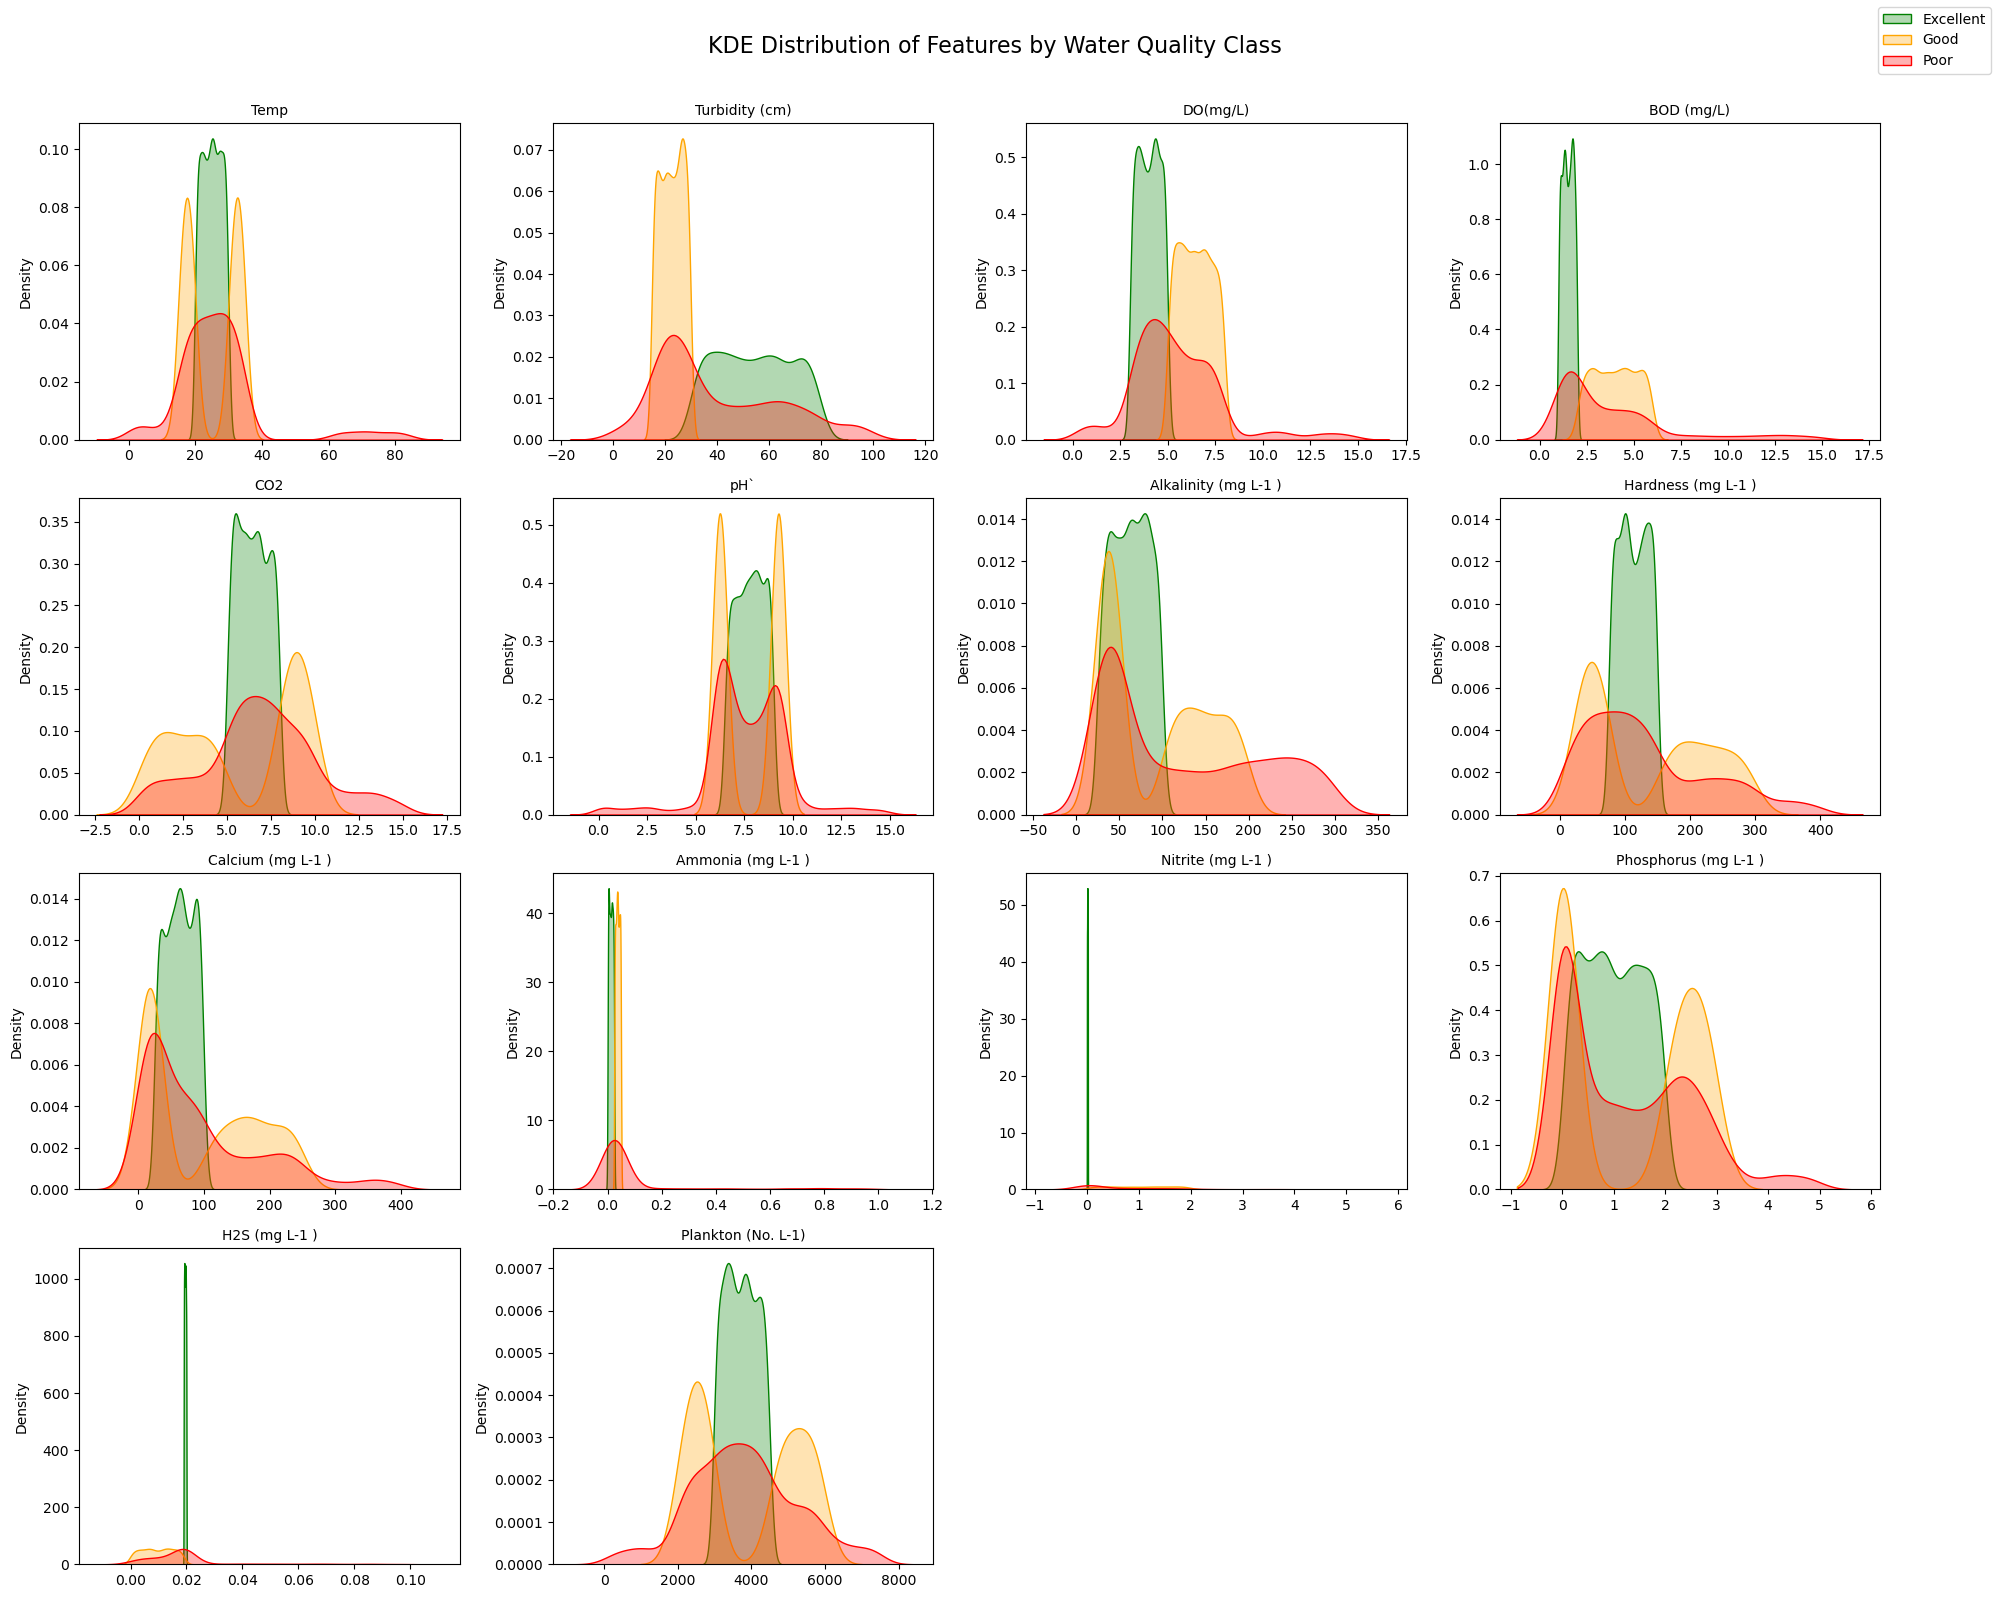

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

features = df.columns[:-2]

class_colors = {0: 'green', 1: 'orange', 2: 'red'}
class_labels = {0: 'Excellent', 1: 'Good', 2: 'Poor'}

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20,16))
axes = axes.flatten()

for i, col in enumerate(features):
    for cls in sorted(df['Water Quality'].unique()):
        sns.kdeplot(
            df[df['Water Quality'] == cls][col],
            ax=axes[i],
            label=class_labels[cls],
            color=class_colors[cls],
            fill=True,
            alpha=0.3
        )
    
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# Remove extra subplot slots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

# Single legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.suptitle("KDE Distribution of Features by Water Quality Class", fontsize=16)
plt.tight_layout(rect=[0,0,0.95,0.97])
plt.show()


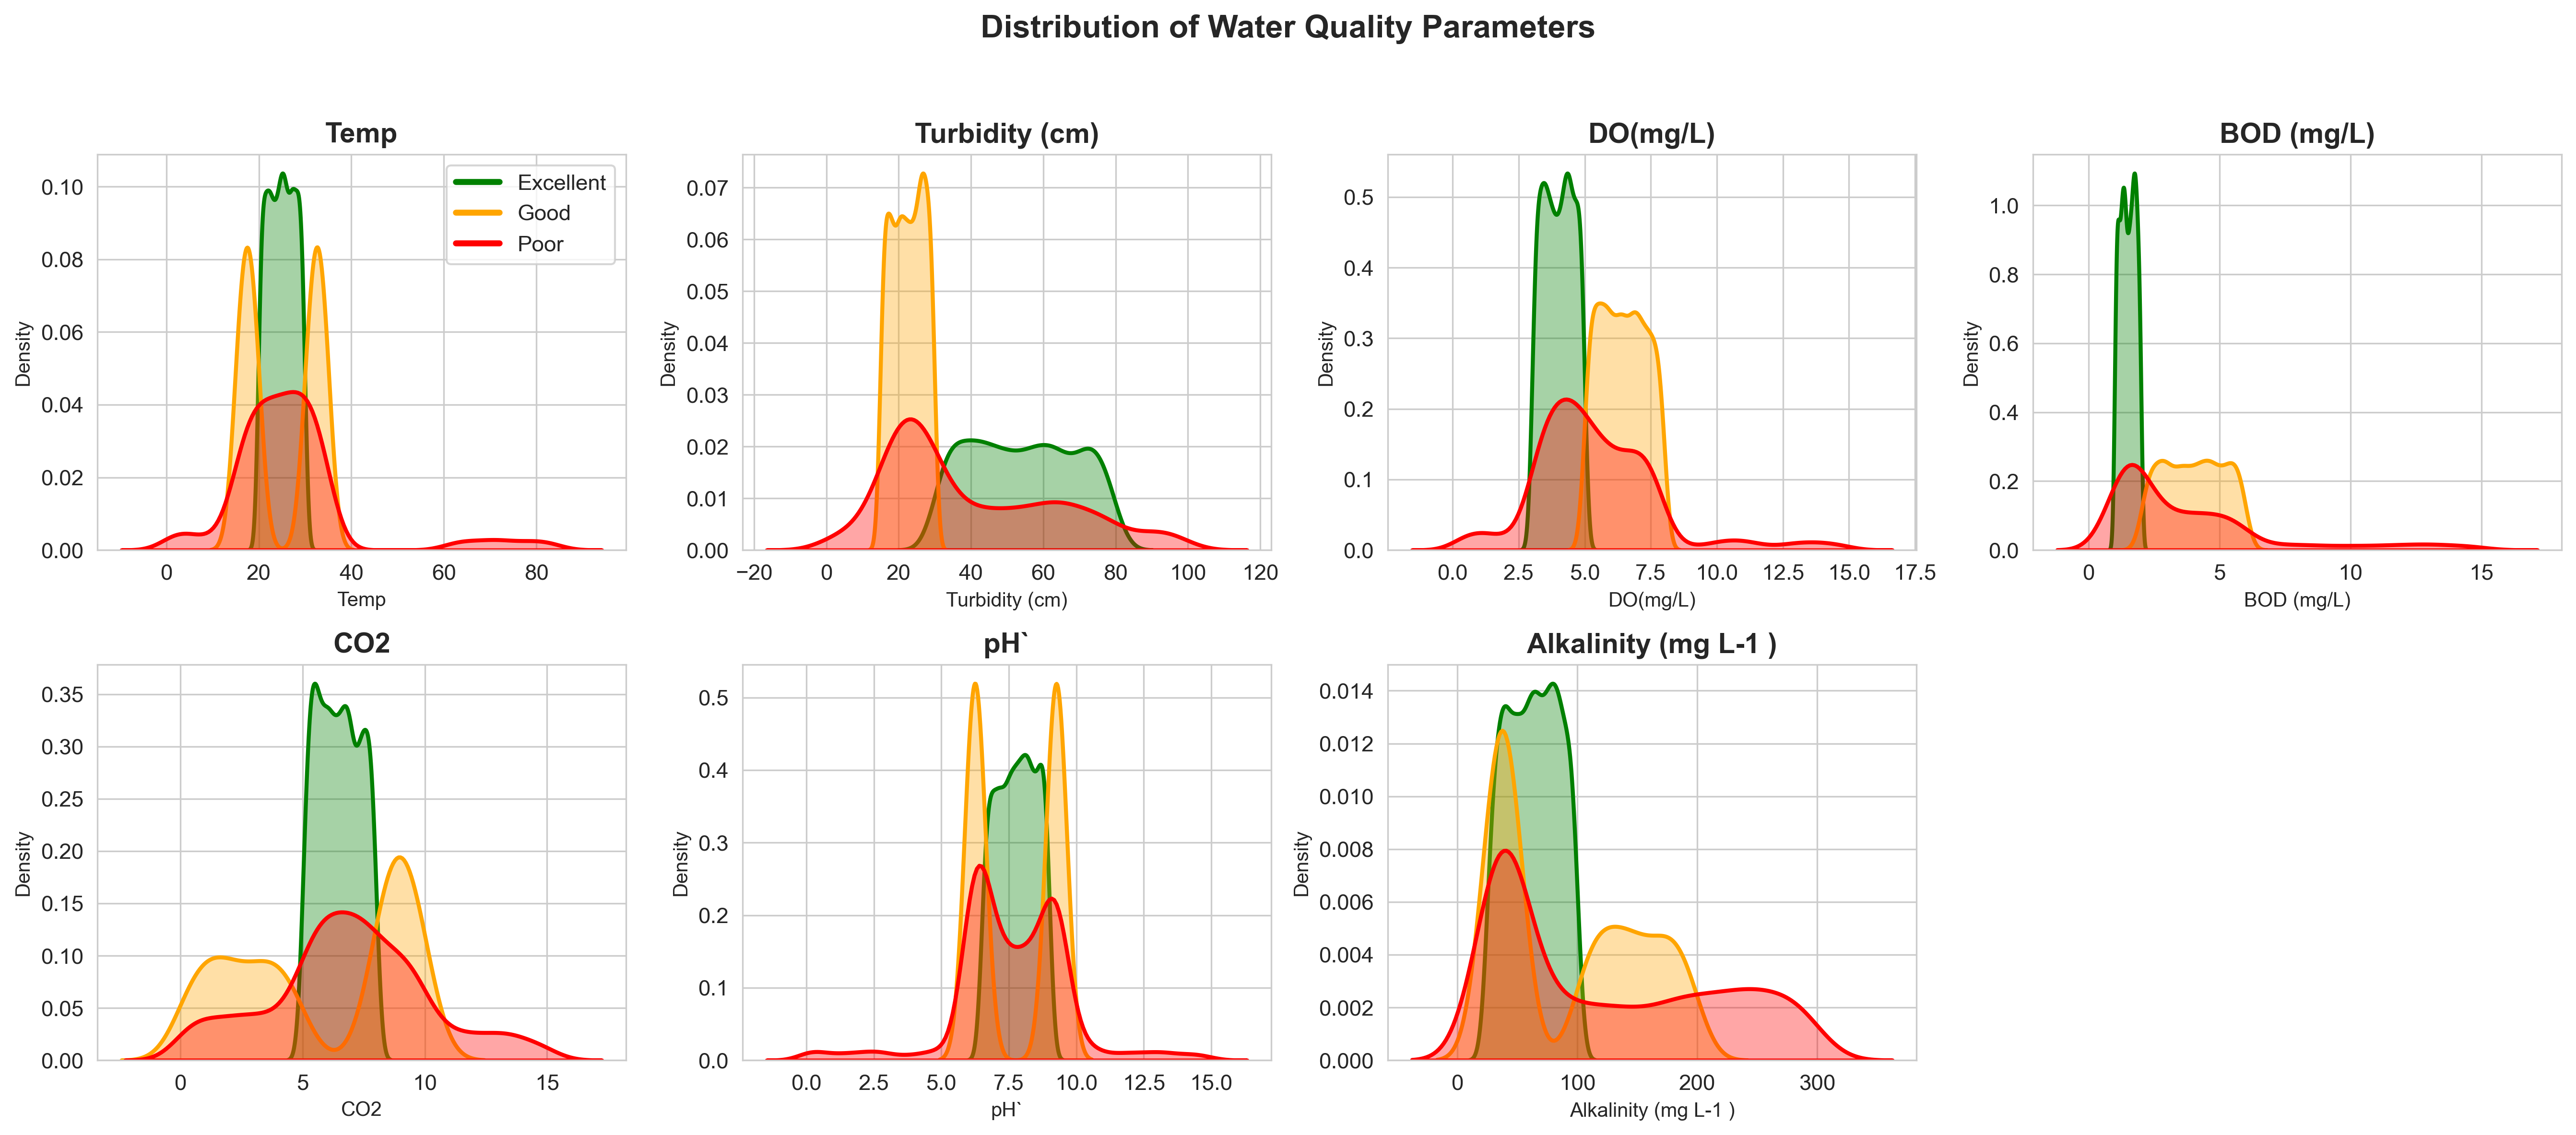

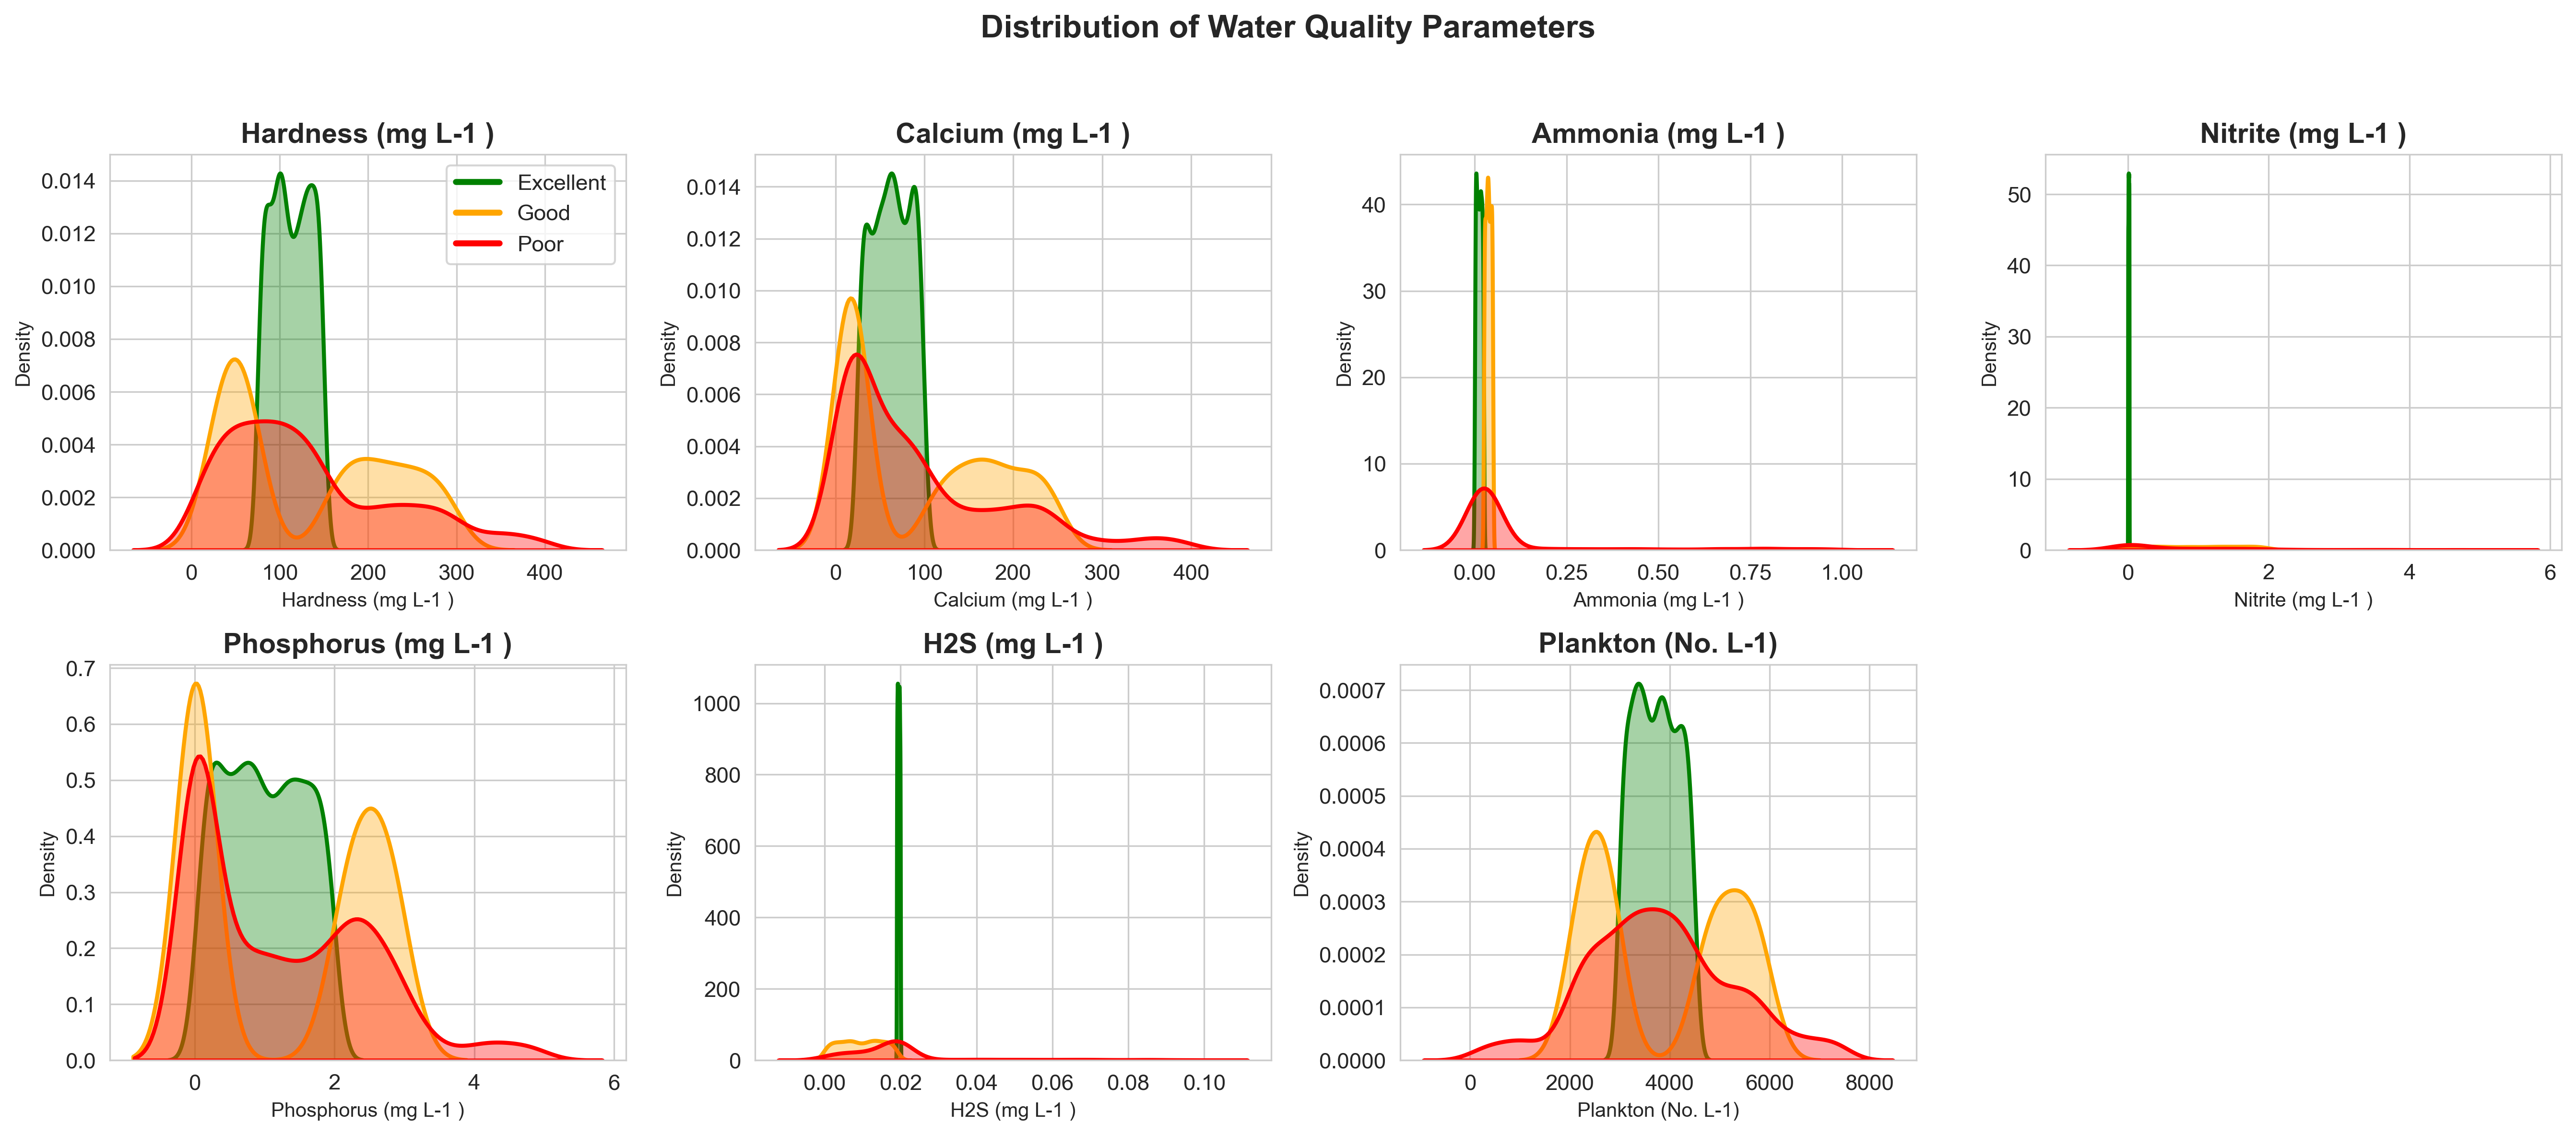

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

features = df.columns[:-2]

class_colors = {0: 'green', 1: 'orange', 2: 'red'}
class_labels = {0: 'Excellent', 1: 'Good', 2: 'Poor'}

sns.set_style("whitegrid")

features1 = features[:7]
features2 = features[7:]

def plot_features(feature_list, title, filename):

    # High-quality figure settings
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), dpi=300)
    axes = axes.flatten()

    for i, col in enumerate(feature_list):

        for cls in sorted(df['Water Quality'].unique()):
            sns.kdeplot(
                df[df['Water Quality'] == cls][col],
                ax=axes[i],
                label=class_labels[cls],
                color=class_colors[cls],
                fill=True,
                alpha=0.35,
                linewidth=2
            )

        axes[i].set_title(col, fontsize=14, fontweight='bold')
        axes[i].tick_params(labelsize=11)

        # Remove legends from each subplot
        if axes[i].get_legend():
            axes[i].get_legend().remove()

    # Remove unused subplot
    for j in range(len(feature_list), len(axes)):
        fig.delaxes(axes[j])

    # Single legend inside first subplot
    handles = [
        plt.Line2D([0], [0], color=class_colors[k], lw=3)
        for k in class_labels
    ]

    axes[0].legend(
        handles,
        class_labels.values(),
        fontsize=11,
        loc="upper right",
        frameon=True
    )

    plt.suptitle(title, fontsize=16, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save as high-quality PNG
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# Save first half features
plot_features(
    features1,
    "Distribution of Water Quality Parameters",
    "water_quality_distribution_part1.png"
)

# Save second half features
plot_features(
    features2,
    "Distribution of Water Quality Parameters",
    "water_quality_distribution_part2.png"
)

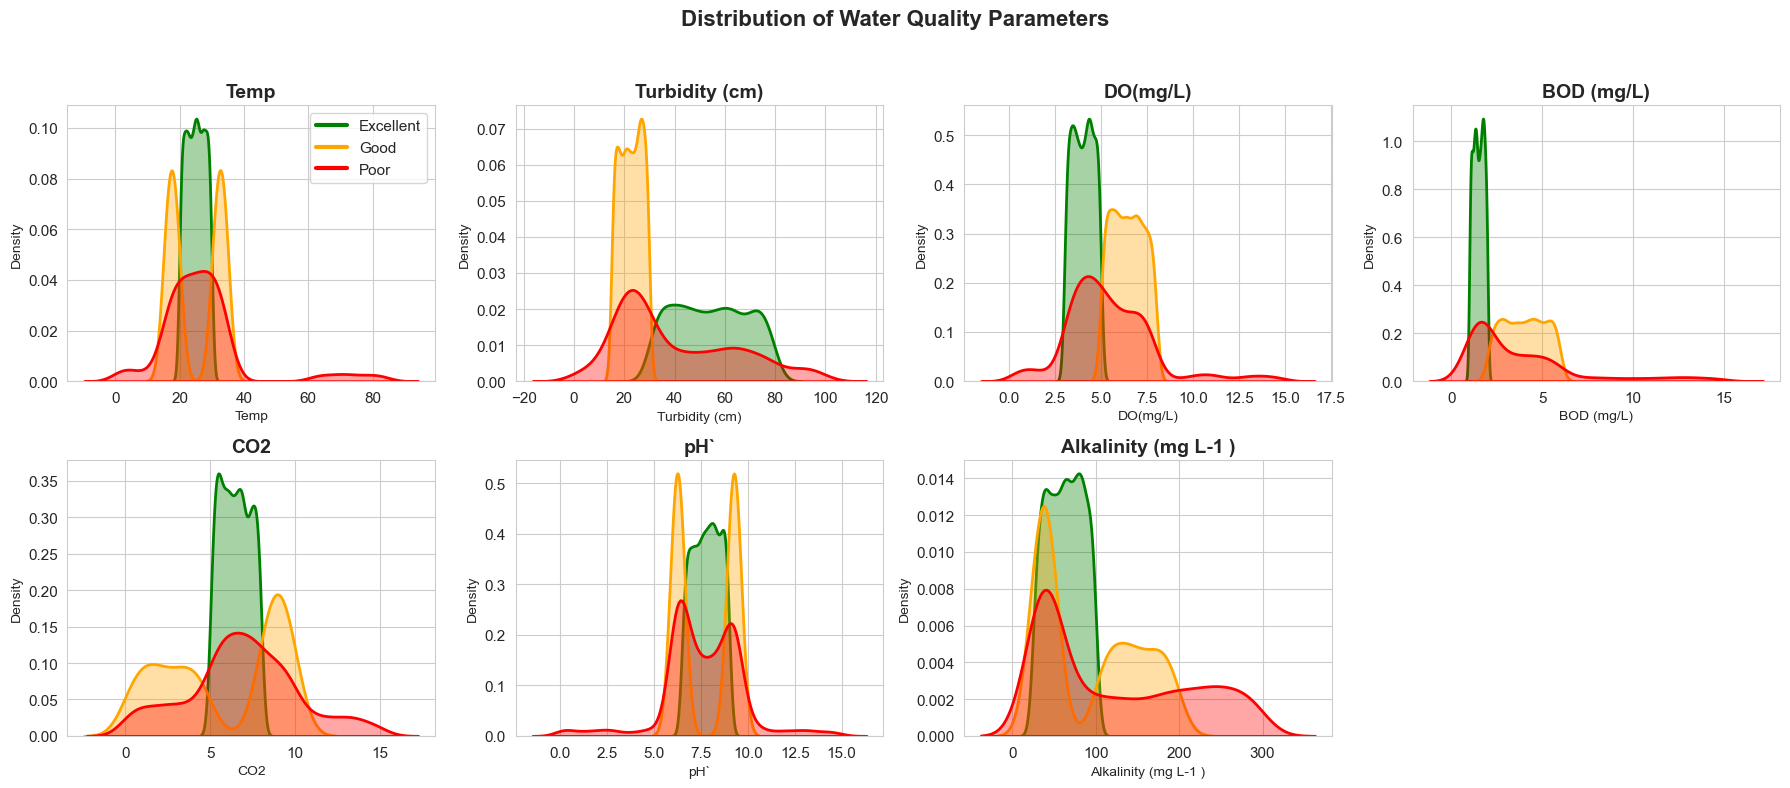

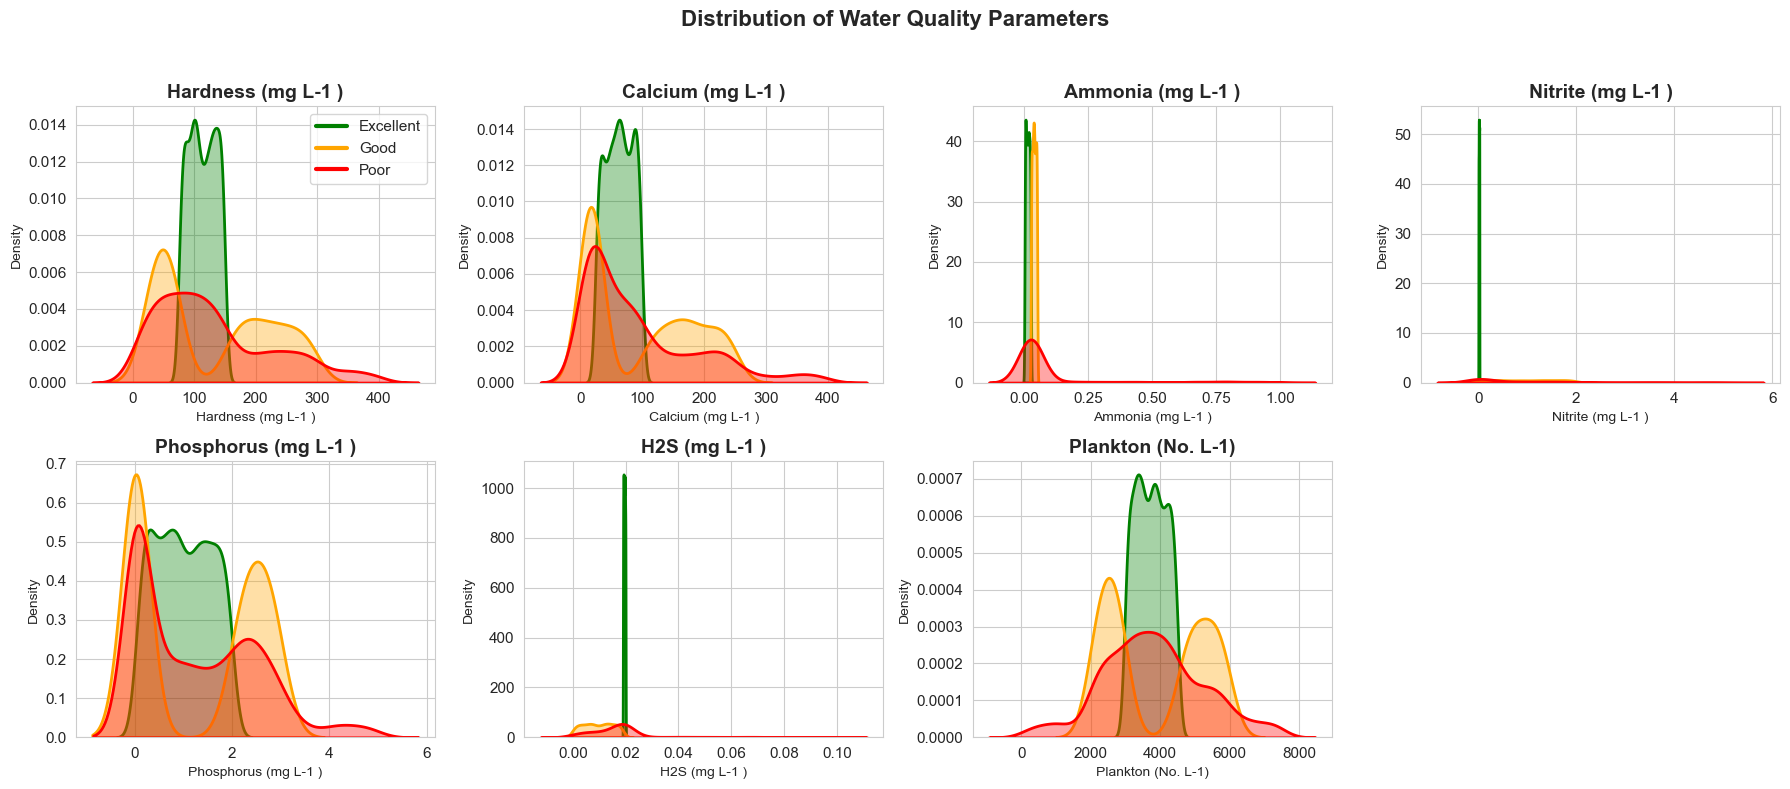

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# features = df.columns[:-2]

# class_colors = {0: 'green', 1: 'orange', 2: 'red'}
# class_labels = {0: 'Excellent', 1: 'Good', 2: 'Poor'}

# sns.set_style("whitegrid")

# features1 = features[:7]
# features2 = features[7:]

# def plot_features(feature_list, title):

#     fig, axes = plt.subplots(2,4, figsize=(18,8))
#     axes = axes.flatten()

#     for i, col in enumerate(feature_list):

#         for cls in sorted(df['Water Quality'].unique()):
#             sns.kdeplot(
#                 df[df['Water Quality']==cls][col],
#                 ax=axes[i],
#                 label=class_labels[cls],
#                 color=class_colors[cls],
#                 fill=True,
#                 alpha=0.35,
#                 linewidth=2
#             )

#         axes[i].set_title(col, fontsize=14, fontweight='bold')
#         axes[i].tick_params(labelsize=11)

#         # remove legends from each subplot
#         if axes[i].get_legend():
#             axes[i].get_legend().remove()

#     # remove unused subplot
#     for j in range(len(feature_list), len(axes)):
#         fig.delaxes(axes[j])

#     # single legend inside first subplot
#     handles = [
#         plt.Line2D([0], [0], color=class_colors[k], lw=3)
#         for k in class_labels
#     ]

#     axes[0].legend(
#         handles,
#         class_labels.values(),
#         fontsize=11,
#         loc="upper right",
#         frameon=True
#     )

#     plt.suptitle(title, fontsize=16, fontweight='bold')

#     plt.tight_layout(rect=[0,0,1,0.95])
#     plt.show()


# plot_features(features1, "Distribution of Water Quality Parameters")
# plot_features(features2, "Distribution of Water Quality Parameters")

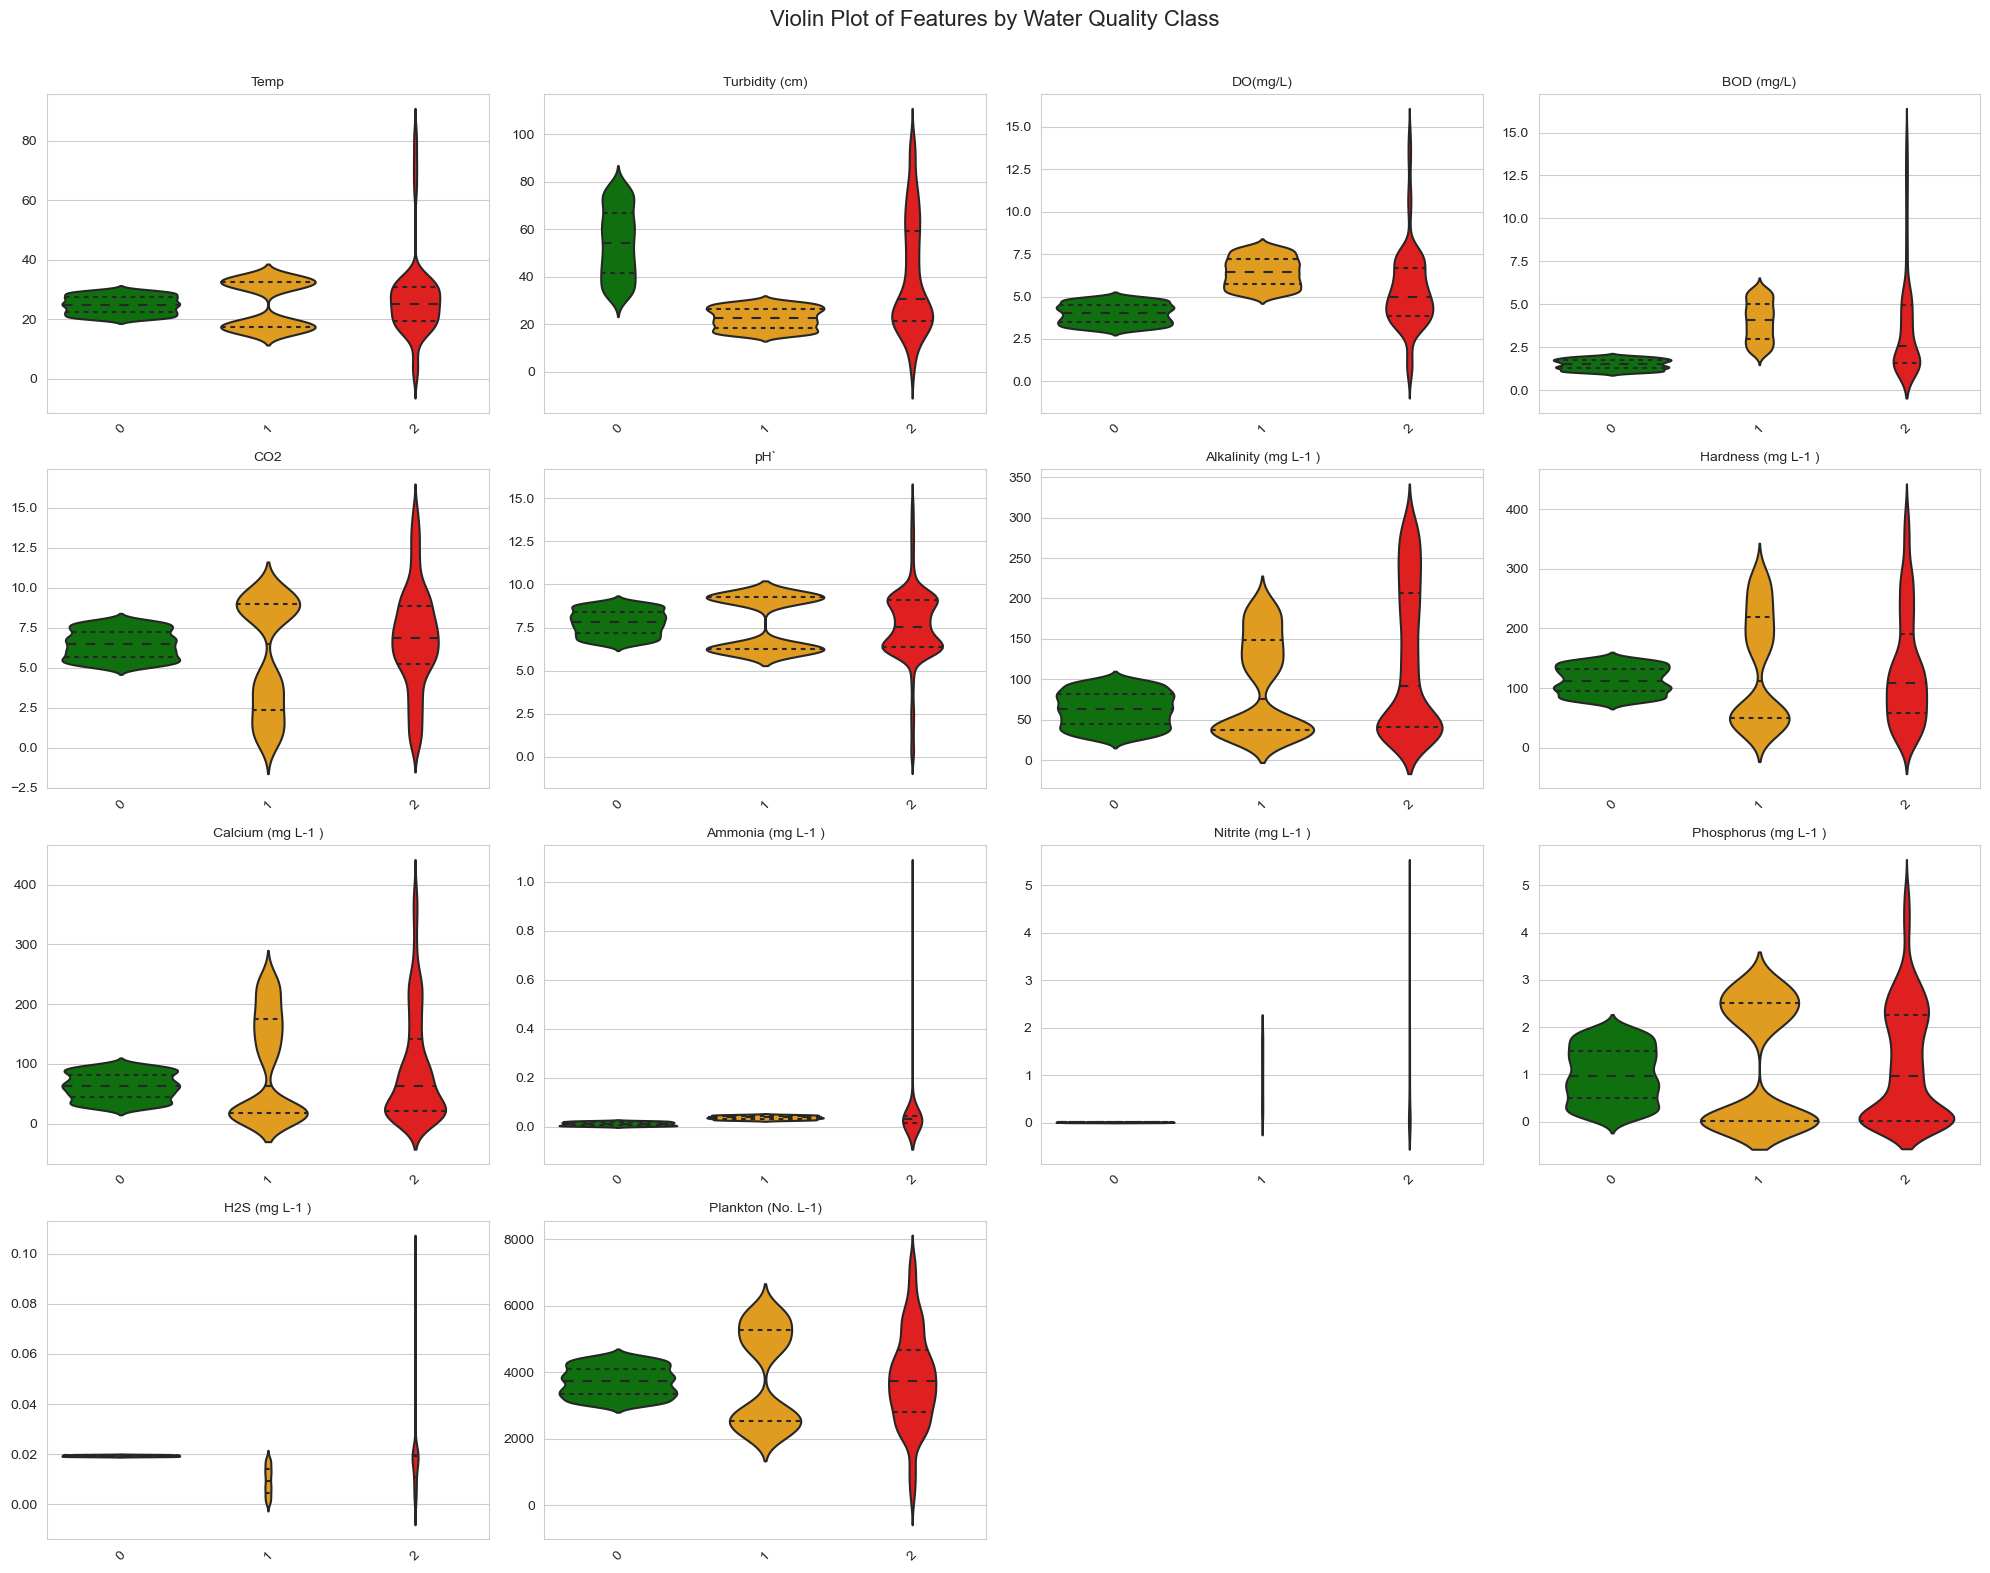

In [19]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20,16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.violinplot(
        x='Water Quality',
        y=col,
        data=df,
        palette=class_colors,
        ax=axes[i],
        inner='quartile'
    )
    
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty slots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Violin Plot of Features by Water Quality Class", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


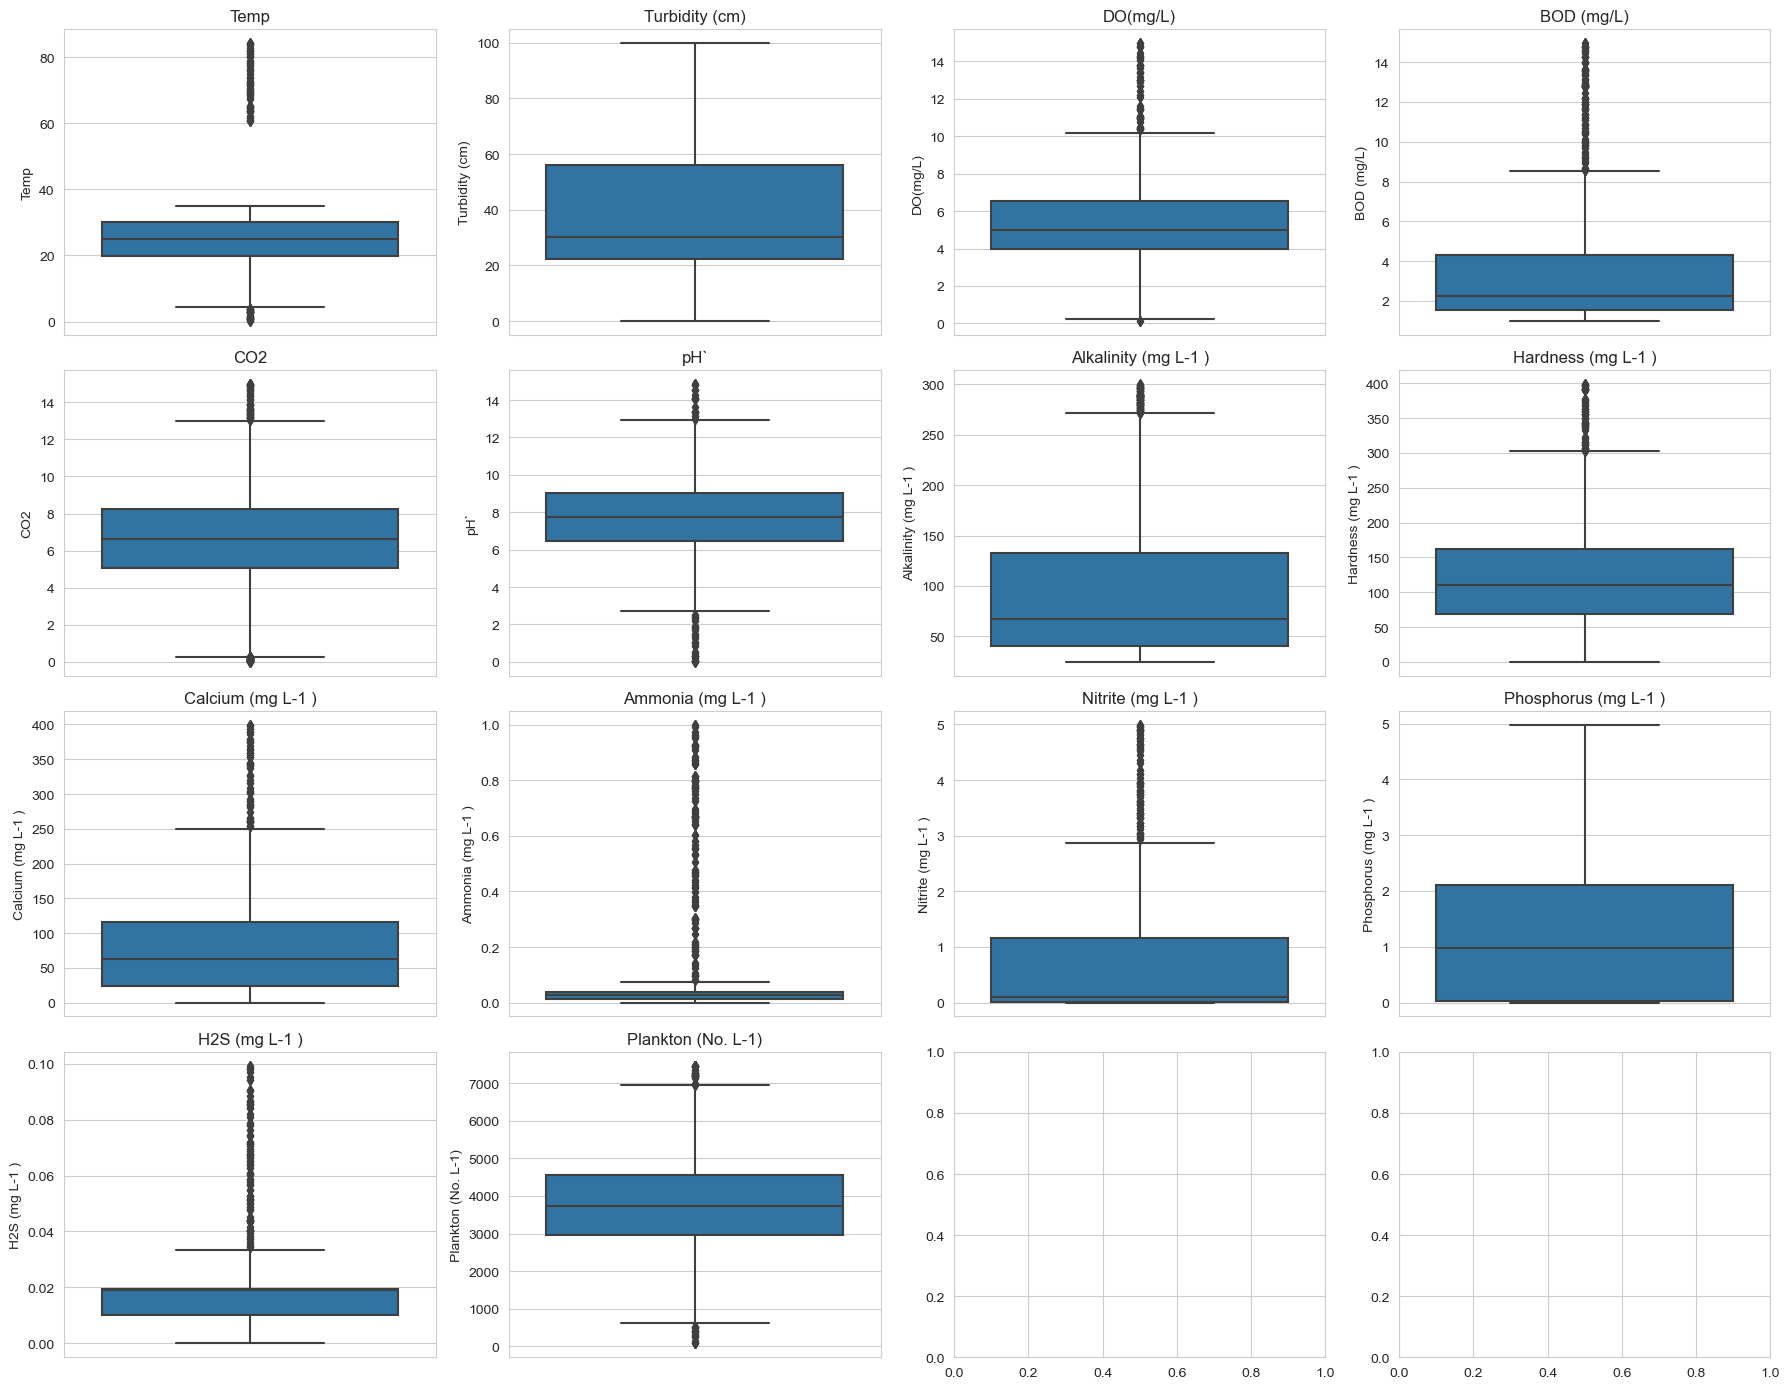

In [20]:
# Boxplots for each feature to inspect outliers
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

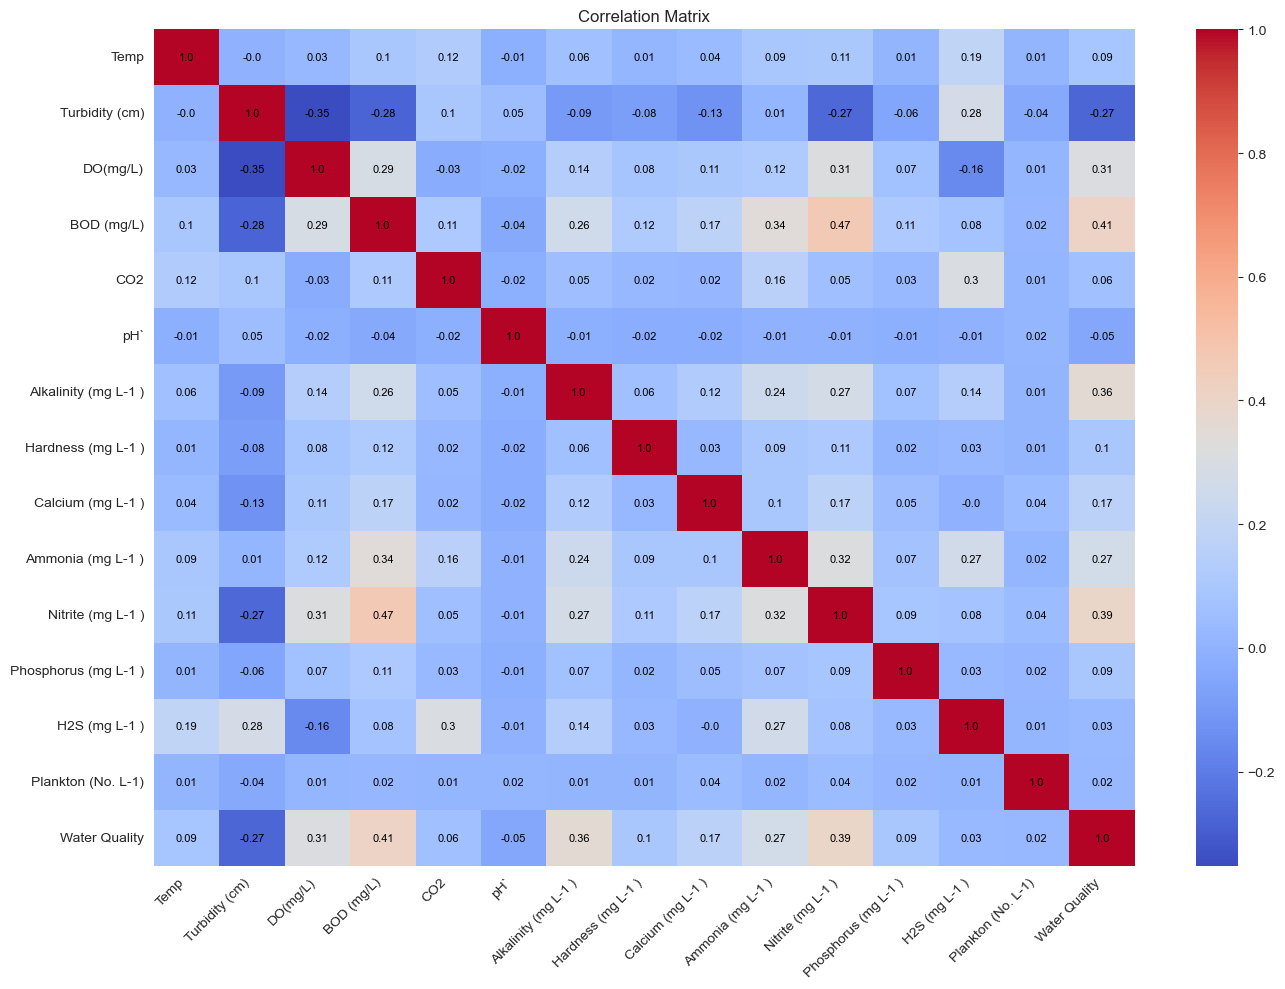

In [21]:
# Correlation matrix for numeric features
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(corr_matrix, cmap='coolwarm', cbar=True)

# Add annotations manually
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j + 0.5, i + 0.5,
                round(corr_matrix.iloc[i, j], 2),
                ha='center',
                va='center',
                color='black',
                fontsize=8)

plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

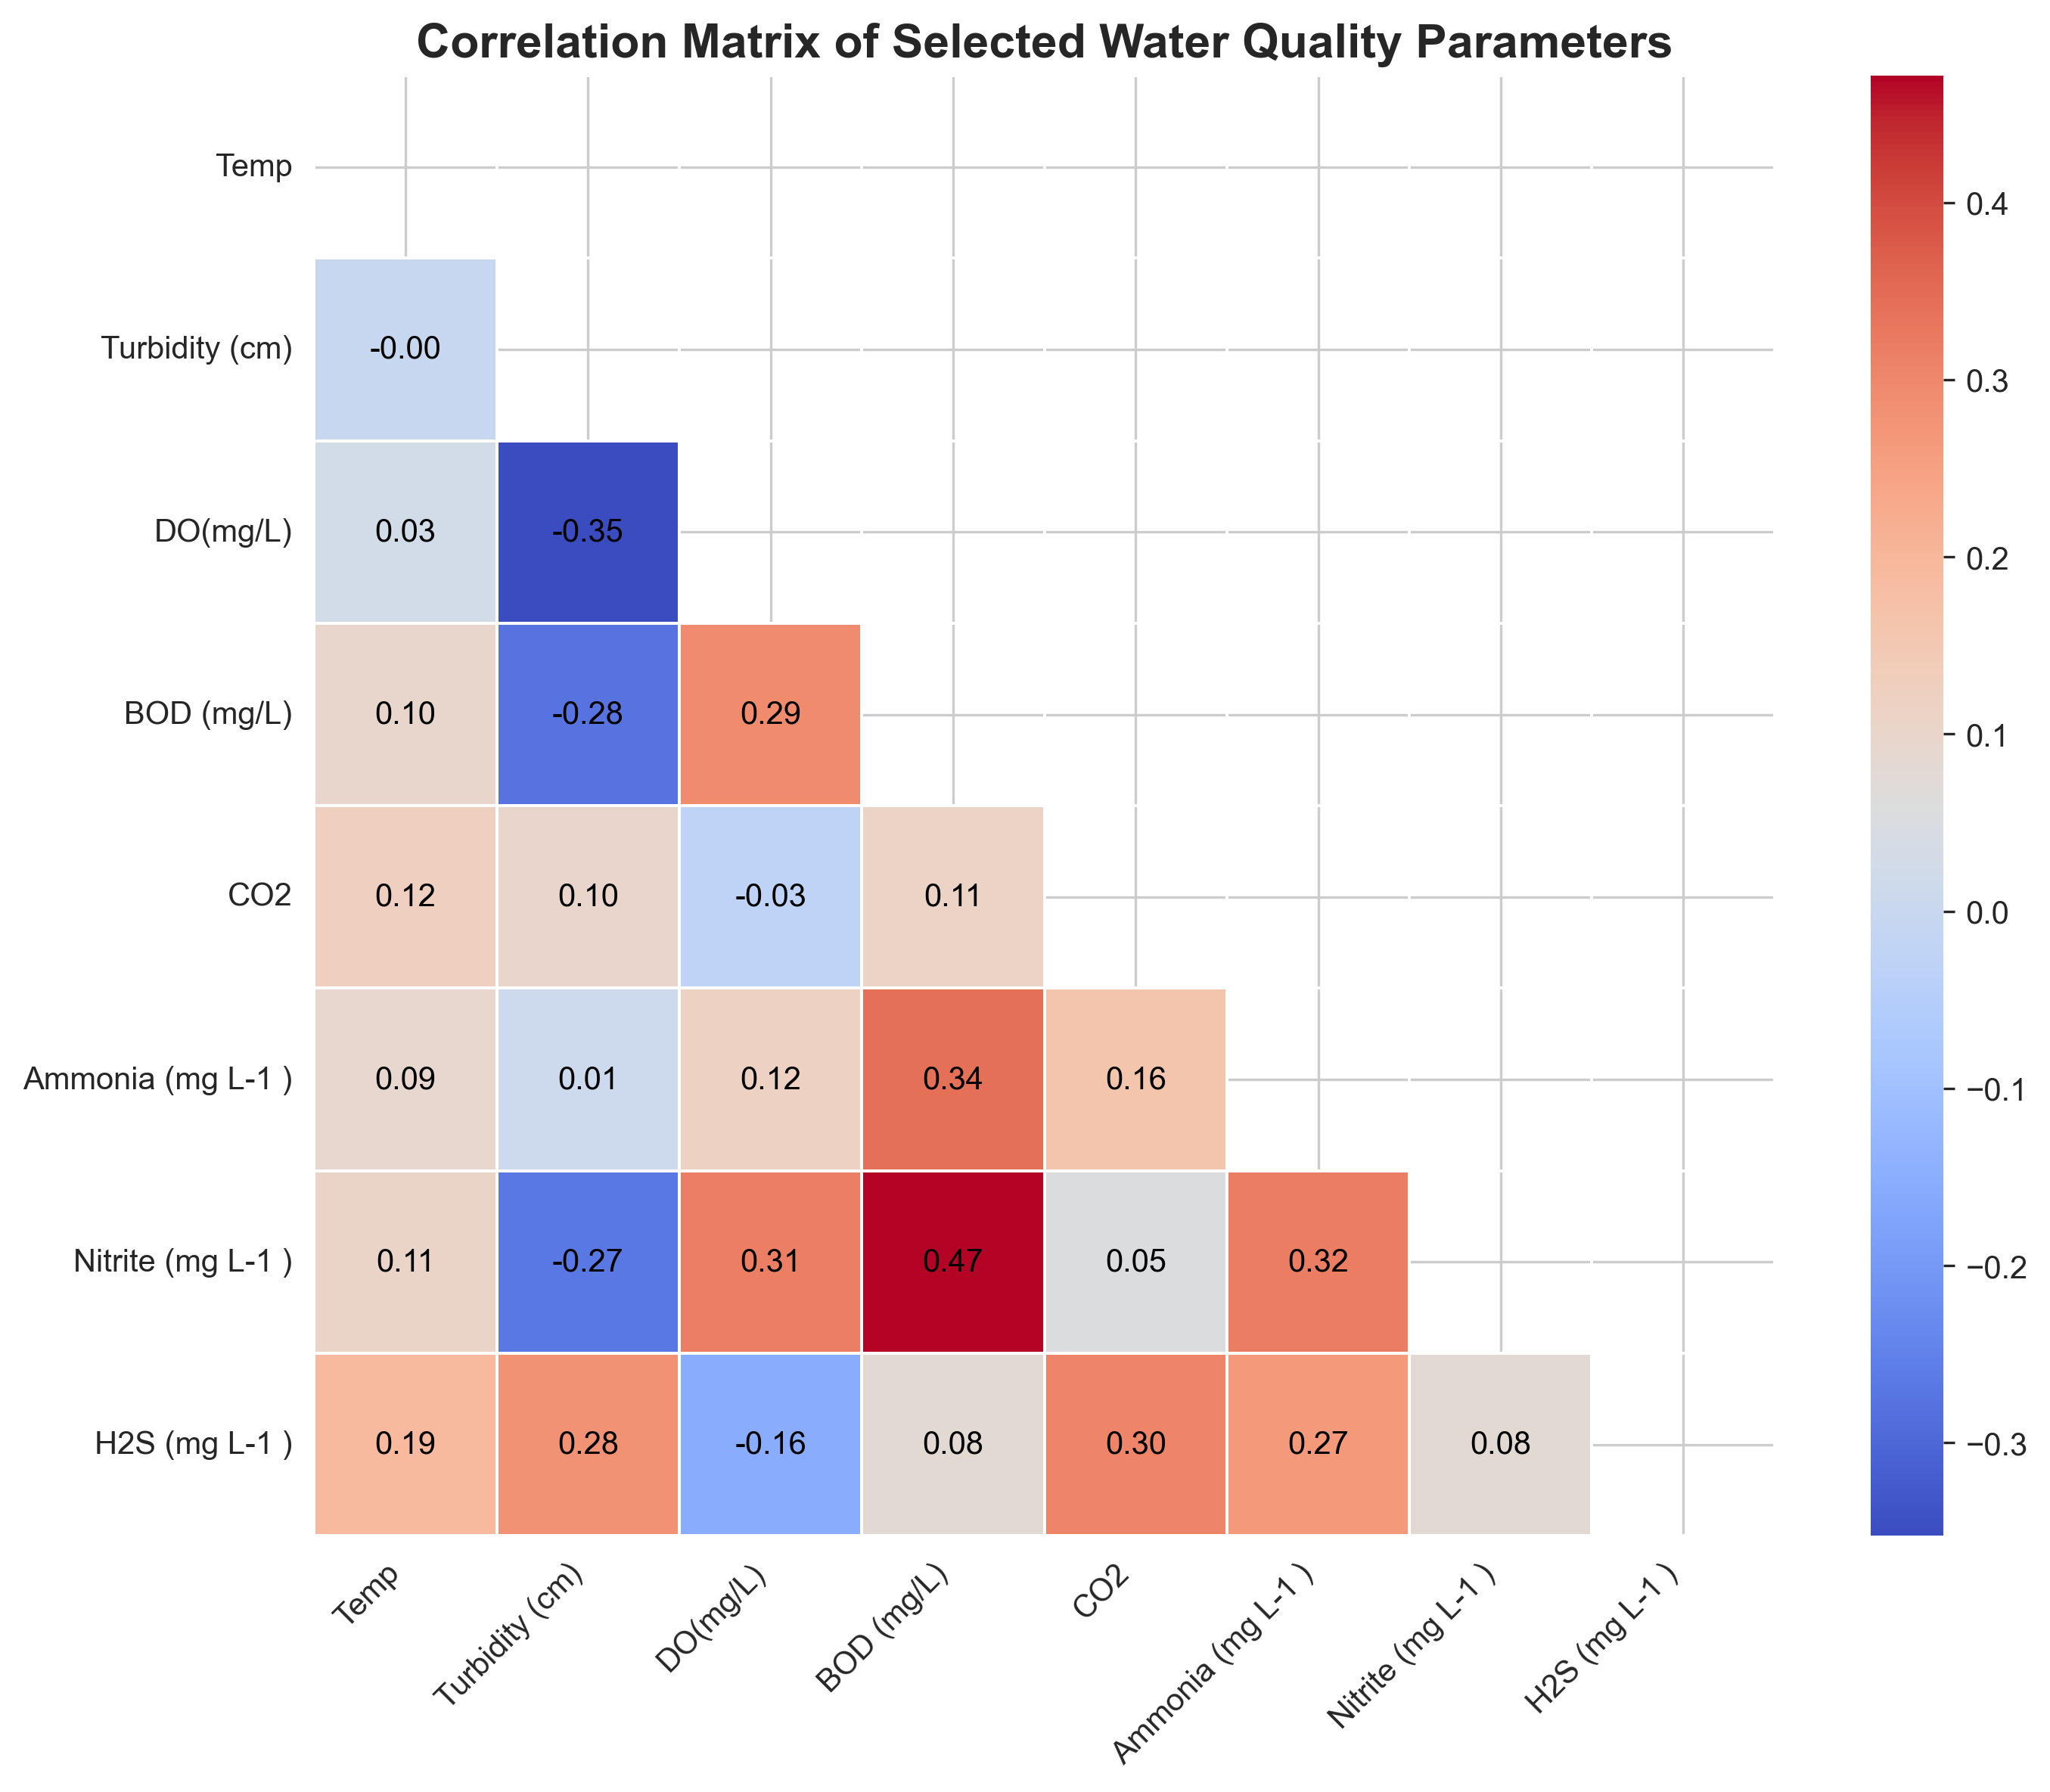

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    "Temp",
    "Turbidity (cm)",
    "DO(mg/L)",
    "BOD (mg/L)",
    "CO2",
    "Ammonia (mg L-1 )",
    "Nitrite (mg L-1 )",
    "H2S (mg L-1 )",
]

df_corr = df[cols]
corr_matrix = df_corr.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# High-quality figure settings
plt.figure(figsize=(10, 8), dpi=300)

ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True,
    square=True
)

# Manual annotation
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        if not mask[i, j]:
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=10
            )

plt.title(
    "Correlation Matrix of Selected Water Quality Parameters",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Save as high-quality PNG
plt.savefig(
    "correlation_matrix_water_quality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

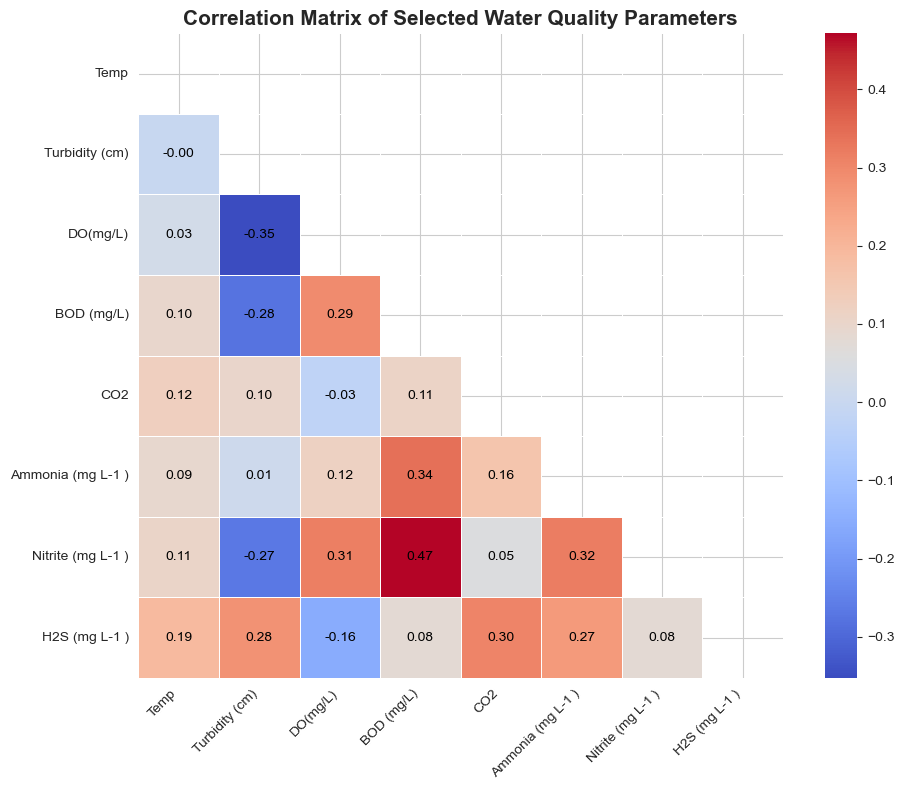

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# cols = [
#     "Temp",
#     "Turbidity (cm)",
#     "DO(mg/L)",
#     "BOD (mg/L)",
#     "CO2",
#     "Ammonia (mg L-1 )",
#     "Nitrite (mg L-1 )",
#     "H2S (mg L-1 )",
# ]

# df_corr = df[cols]
# corr_matrix = df_corr.corr()

# # mask upper triangle
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# plt.figure(figsize=(10,8))

# ax = sns.heatmap(
#     corr_matrix,
#     mask=mask,
#     cmap="coolwarm",
#     linewidths=0.5,
#     cbar=True,
#     square=True
# )

# # manual annotation
# for i in range(len(corr_matrix)):
#     for j in range(len(corr_matrix)):
#         if not mask[i, j]:
#             ax.text(
#                 j + 0.5,
#                 i + 0.5,
#                 f"{corr_matrix.iloc[i, j]:.2f}",
#                 ha="center",
#                 va="center",
#                 color="black",
#                 fontsize=10
#             )

# plt.title(
#     "Correlation Matrix of Selected Water Quality Parameters",
#     fontsize=15,
#     fontweight="bold"
# )

# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)

# plt.tight_layout()
# plt.show()

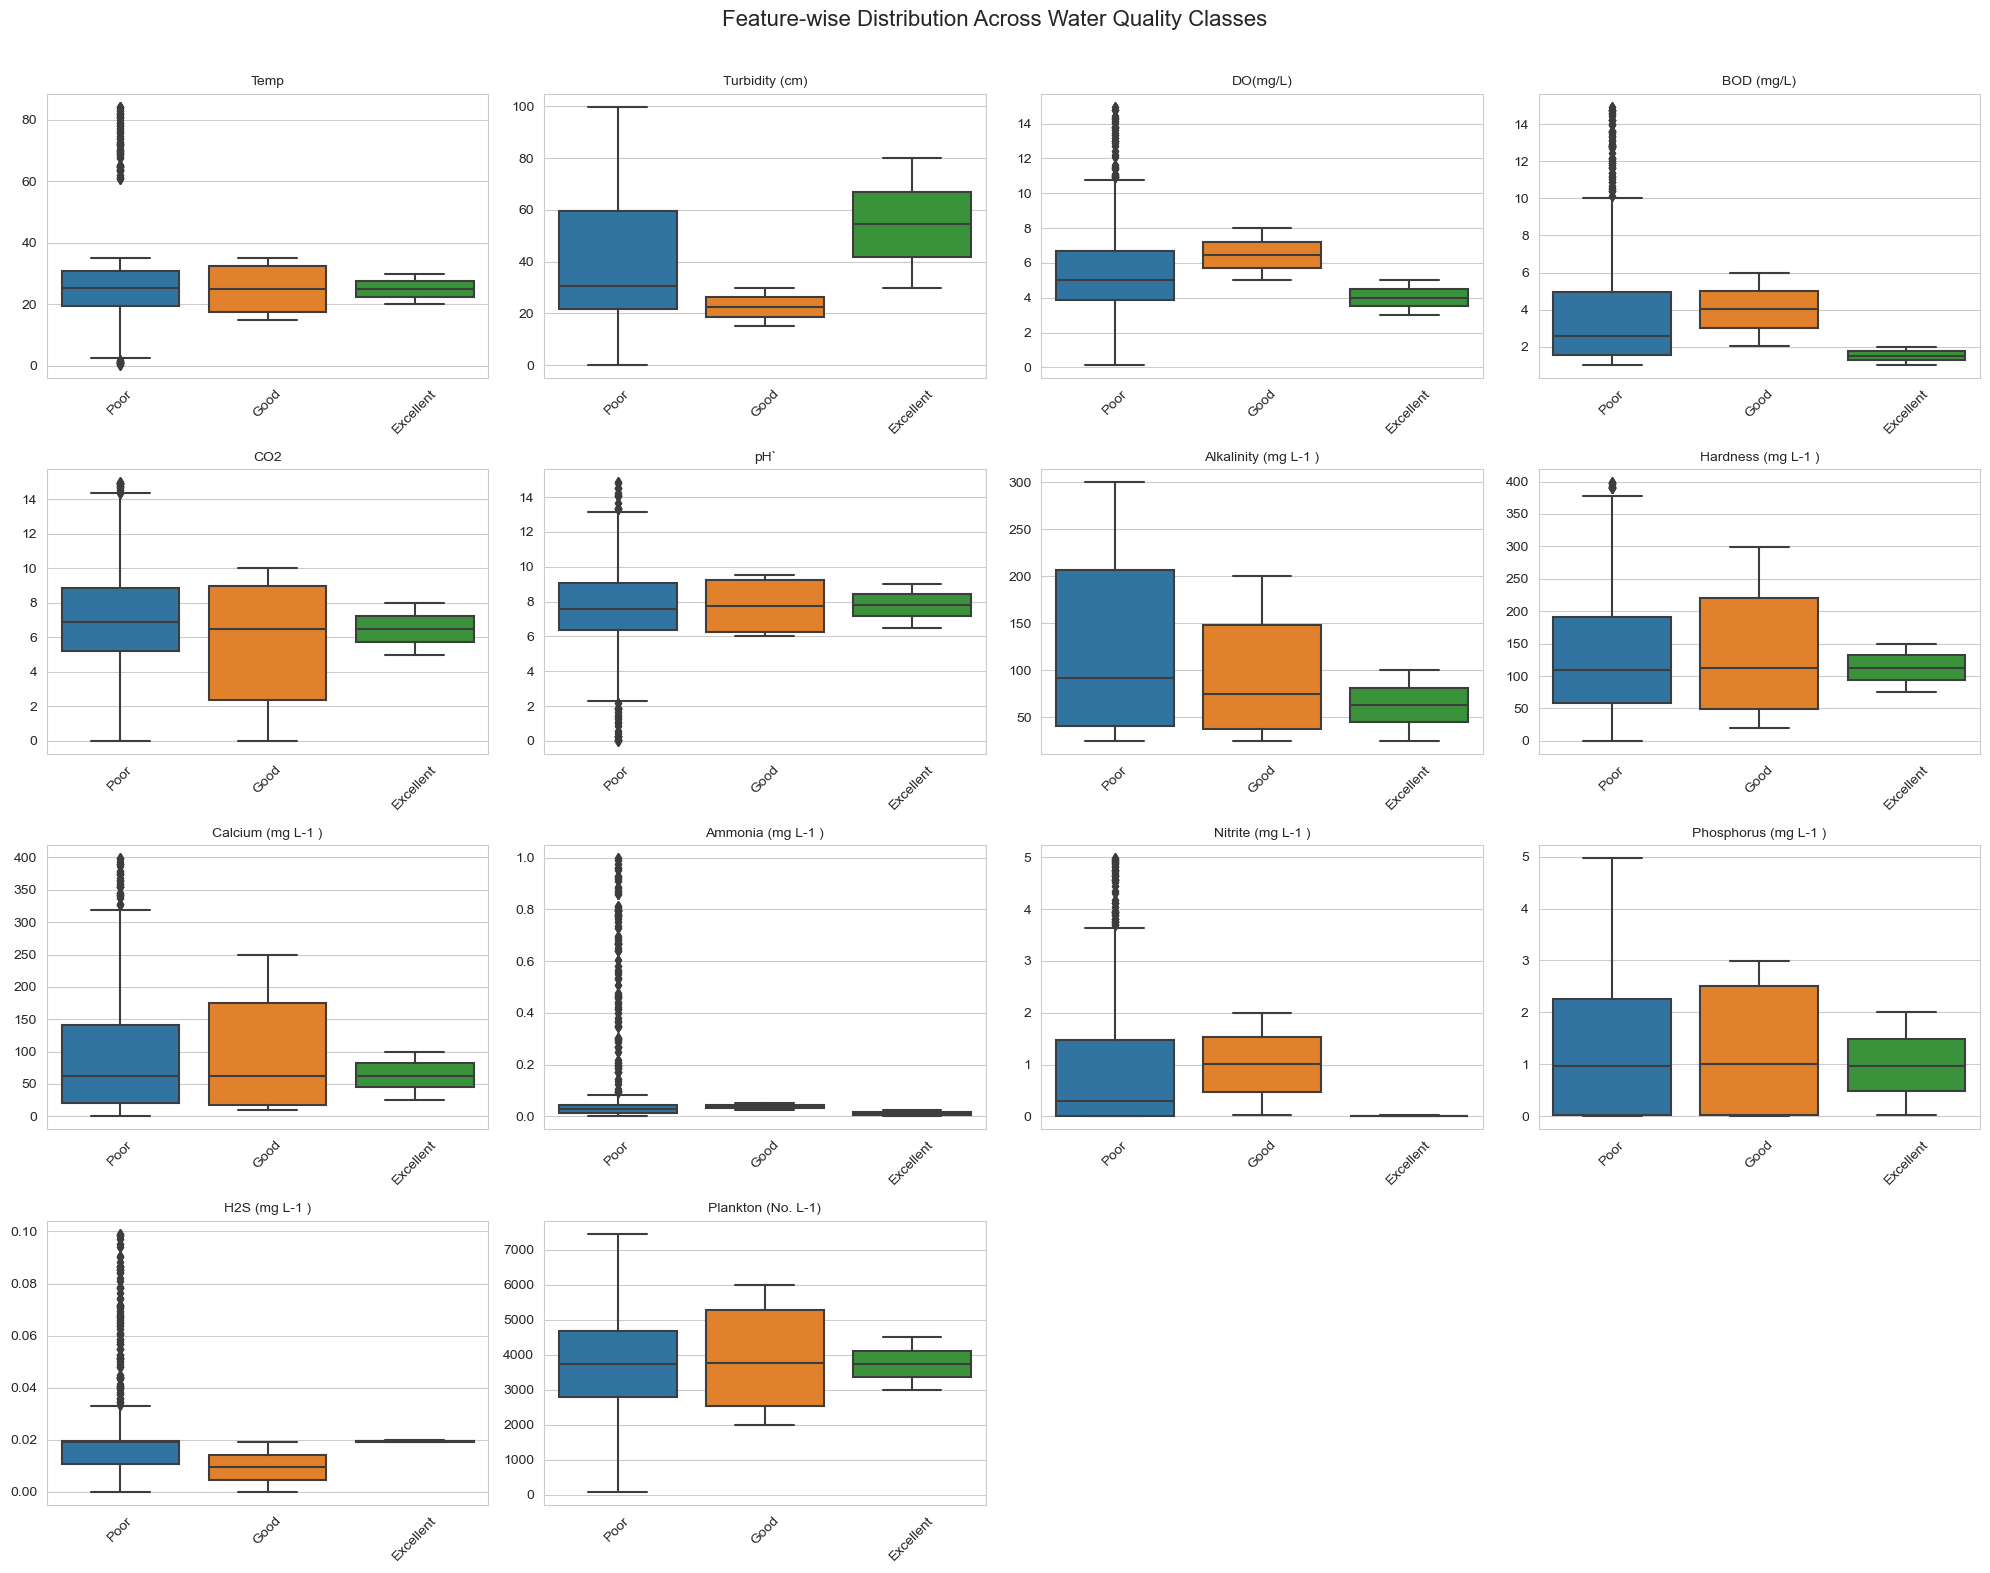

In [23]:
# Boxplots grouped by water quality class
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    sns.boxplot(
        x='Water_Label',
        y=col,
        data=df,
        ax=axes[i]
    )
    
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature-wise Distribution Across Water Quality Classes", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Statistical tests
Use ANOVA to test whether feature means differ across water quality classes.

In [24]:
from scipy import stats

anova_results = []

for col in feature_columns:
    groups = [
        df[df['Water Quality'] == cls][col].values
        for cls in sorted(df['Water Quality'].unique())
    ]
    f_val, p_val = stats.f_oneway(*groups)
    anova_results.append({
        'Feature': col,
        'F-Statistic': f_val,
        'P-Value': p_val,
        'Significant (p<0.05)': p_val < 0.05
    })

anova_df = pd.DataFrame(anova_results)
anova_df = anova_df.sort_values('P-Value')
anova_df['F-Statistic'] = anova_df['F-Statistic'].round(3)
anova_df['P-Value'] = anova_df['P-Value'].apply(lambda x: f"{x:.3e}")
anova_df

,Feature,F-Statistic,P-Value,Significant (p<0.05)
1,Turbidity (cm),1314.856,0.000e+00,True
2,DO(mg/L),897.268,0.000e+00,True
3,BOD (mg/L),698.004,3.192e-263,True
10,Nitrite (mg L-1 ),677.909,1.301e-256,True
12,H2S (mg L-1 ),427.343,5.403e-170,True
6,Alkalinity (mg L-1 ),312.211,2.507e-127,True
9,Ammonia (mg L-1 ),172.174,1.177e-72,True
8,Calcium (mg L-1 ),93.324,2.115e-40,True
4,CO2,66.378,4.062e-29,True
7,Hardness (mg L-1 ),35.011,8.270e-16,True


## Pairwise relationships
Visualize pairwise relationships between selected features colored by water quality label.

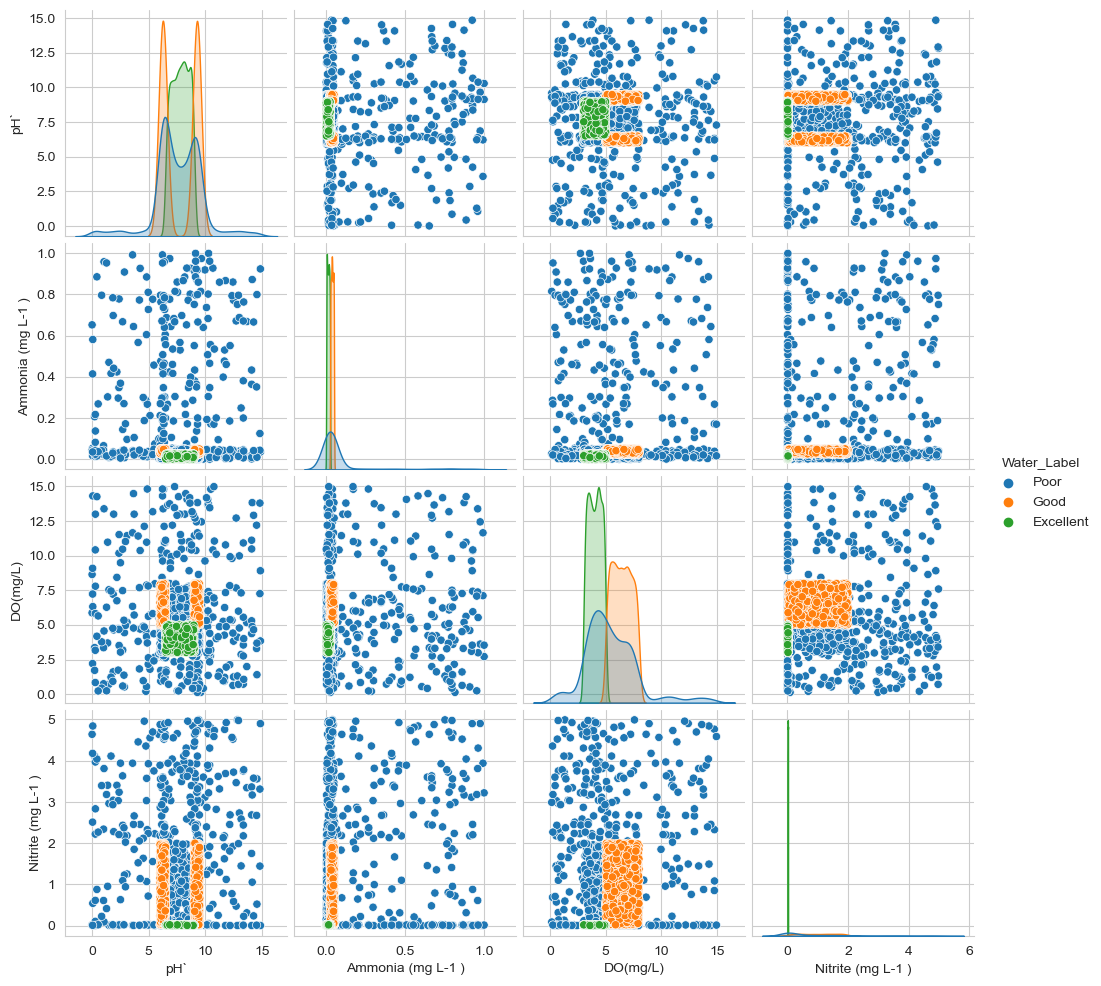

In [25]:
sns.pairplot(df[['pH`', 'Ammonia (mg L-1 )', 'DO(mg/L)',
                 'Nitrite (mg L-1 )', 'Water_Label']],
             hue='Water_Label')
plt.show()

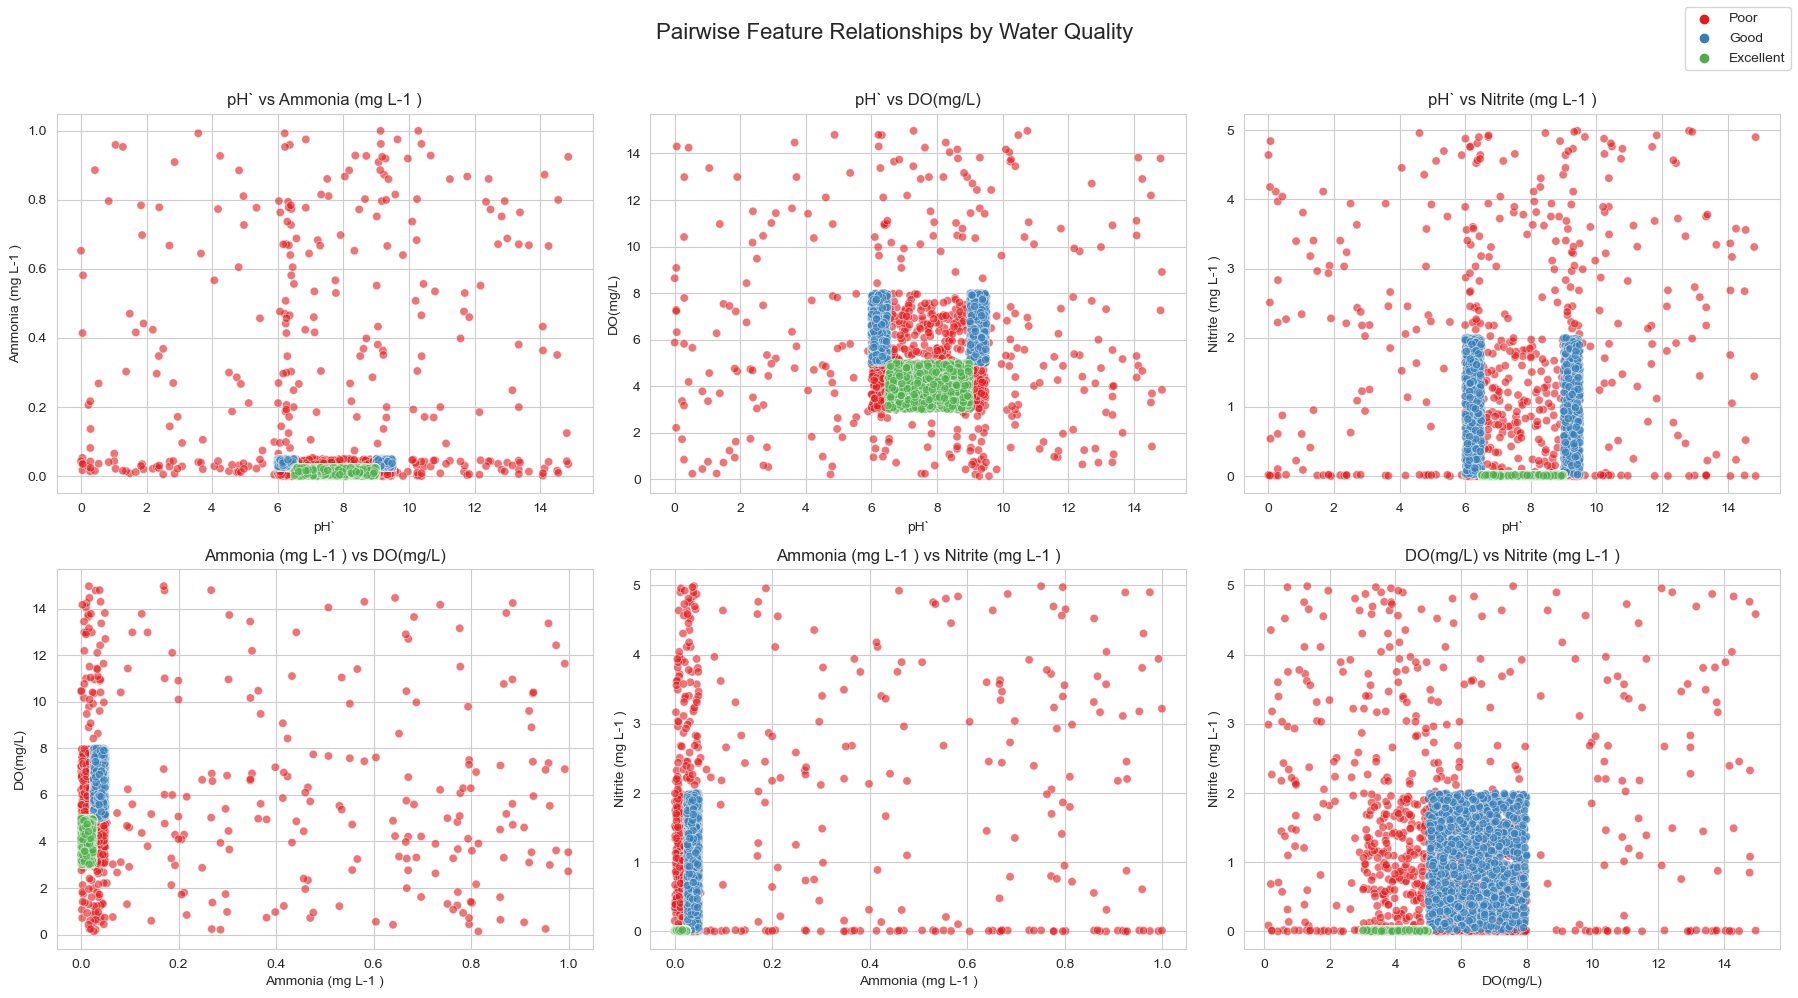

In [26]:
import itertools

selected_features = ['pH`', 'Ammonia (mg L-1 )',
                     'DO(mg/L)', 'Nitrite (mg L-1 )']
pairs = list(itertools.combinations(selected_features, 2))

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, (x_feat, y_feat) in enumerate(pairs):
    sns.scatterplot(
        x=df[x_feat],
        y=df[y_feat],
        hue=df['Water_Label'],
        palette='Set1',
        alpha=0.6,
        ax=axes[i],
    )
    axes[i].set_xlabel(x_feat)
    axes[i].set_ylabel(y_feat)
    axes[i].set_title(f"{x_feat} vs {y_feat}")
    axes[i].legend().remove()

for j in range(len(pairs), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Pairwise Feature Relationships by Water Quality", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.show()

## Principal Component Analysis (PCA)
Standardize features and compute a 2-component PCA for visualization.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare feature matrix
feature_matrix = df.drop(['Water Quality', 'Water_Label'], axis=1)

scaler = StandardScaler()
feature_matrix_scaled = scaler.fit_transform(feature_matrix)

pca = PCA(n_components=2)
feature_matrix_pca = pca.fit_transform(feature_matrix_scaled)


In [28]:
# Colors and labels for plotting
class_colors = {0: 'green', 1: 'orange', 2: 'red'}
class_labels = {0: 'Excellent', 1: 'Good', 2: 'Poor'}

In [29]:
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

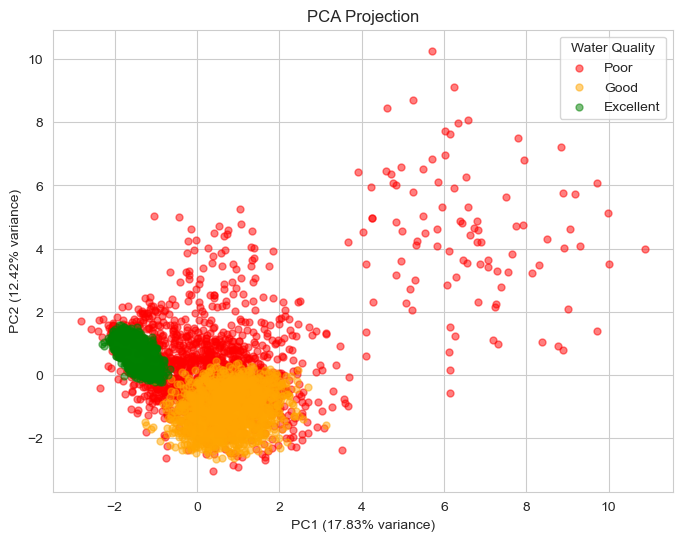

In [30]:
# Scatter plot of PCA projection
plt.figure(figsize=(8, 6))
plot_order = [2, 1, 0]  # Poor first, Excellent last

for cls in plot_order:
    plt.scatter(
        feature_matrix_pca[df['Water Quality'] == cls, 0],
        feature_matrix_pca[df['Water Quality'] == cls, 1],
        label=class_labels[cls],
        color=class_colors[cls],
        alpha=0.5,
        s=25
    )

plt.xlabel(f"PC1 ({pc1_var:.2f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.2f}% variance)")
plt.title("PCA Projection")
plt.legend(title="Water Quality")
plt.grid(True)
plt.show()

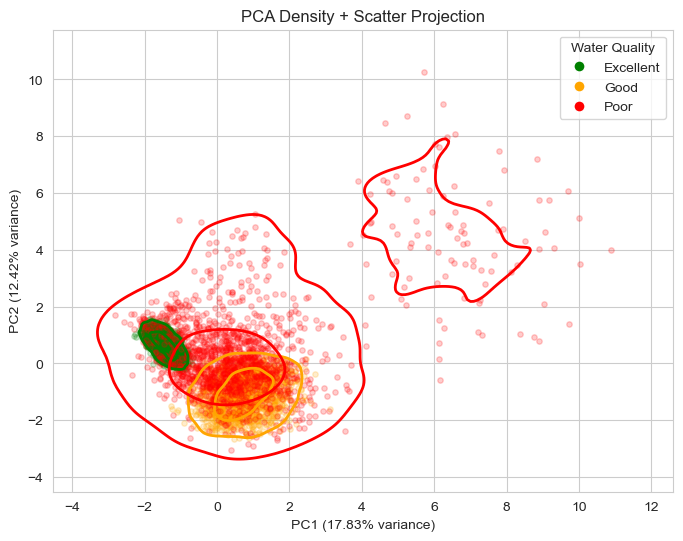

In [31]:
# KDE contours over PCA projection
plt.figure(figsize=(8, 6))

for cls in sorted(df['Water Quality'].unique()):
    mask = df['Water Quality'] == cls
    sns.kdeplot(
        x=feature_matrix_pca[mask, 0],
        y=feature_matrix_pca[mask, 1],
        levels=3,
        linewidths=2,
        color=class_colors[cls],
    )
    plt.scatter(
        feature_matrix_pca[mask, 0],
        feature_matrix_pca[mask, 1],
        color=class_colors[cls],
        alpha=0.2,
        s=15,
        label=class_labels[cls],
    )

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=class_labels[cls],
           markerfacecolor=class_colors[cls],
           markersize=8)
    for cls in sorted(class_labels.keys())
]
plt.legend(handles=legend_elements, title='Water Quality')
plt.xlabel(f"PC1 ({pc1_var:.2f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.2f}% variance)")
plt.title("PCA Density + Scatter Projection")
plt.grid(True)
plt.show()

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Separate features
X = df.drop(['Water Quality', 'Water_Label'], axis=1)
y = df['Water Quality']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))


Explained Variance Ratio: [0.17831739 0.12423498 0.07327926]
Total Variance Explained: 0.375831623160795


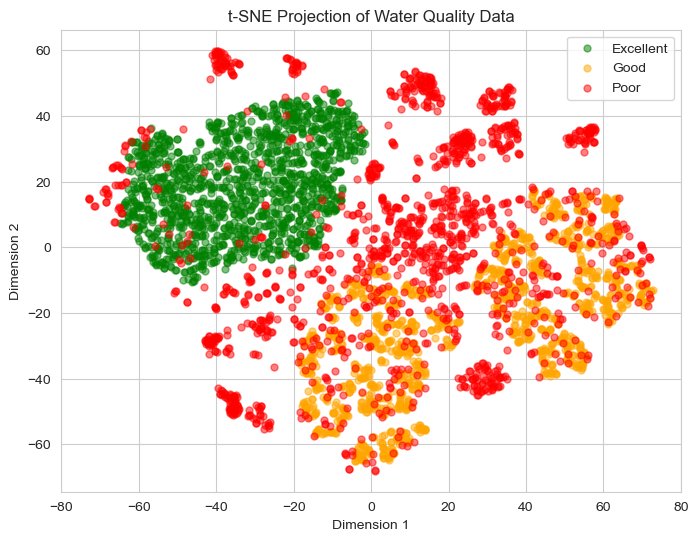

In [34]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for cls in sorted(np.unique(y)):
    mask = y == cls
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=class_labels[cls],
        color=class_colors[cls],
        alpha=0.5,
        s=25
    )

plt.legend()
plt.title("t-SNE Projection of Water Quality Data")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


In [35]:
X_scaled

array([[ 4.31820519, -1.38104738, -2.77878775, ..., -1.07782204,
         4.23836255,  1.87363441],
       [ 4.02634087,  2.62503113,  3.34736118, ..., -1.07881734,
         0.58579841, -2.94148738],
       [ 4.07755317,  2.46447304,  3.89109345, ..., -1.07690223,
         4.09081407,  2.82472392],
       ...,
       [ 0.13163186,  0.27691761, -0.54046285, ..., -0.41187928,
         0.22190743,  0.00904771],
       [-0.12127017,  0.86349879, -0.30380537, ..., -0.31865414,
         0.28903174, -0.18579933],
       [-0.13039672,  1.77529219, -0.47721068, ..., -0.26006413,
         0.23514919, -0.18311416]])

In [36]:
pca = PCA(n_components=None)
pca.fit(X_scaled)

print(pca.explained_variance_ratio_)
print("Cumulative variance:", np.cumsum(pca.explained_variance_ratio_))


[0.17831739 0.12423498 0.07327926 0.07180419 0.07060033 0.06977792
 0.06754572 0.06391767 0.06098089 0.0541181  0.04696511 0.04272044
 0.03896753 0.03677049]
Cumulative variance: [0.17831739 0.30255237 0.37583162 0.44763581 0.51823614 0.58801405
 0.65555978 0.71947745 0.78045834 0.83457644 0.88154154 0.92426198
 0.96322951 1.        ]


#### The relatively low variance captured by the first two principal components (30.2%) indicates that the physicochemical parameters contribute in a distributed manner across multiple orthogonal axes, suggesting complex nonlinear interactions.

In [37]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [38]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)

print(loadings)


                           PC1       PC2       PC3
Temp                  0.136501  0.240377 -0.013998
Turbidity (cm)       -0.274566  0.461542  0.028457
DO(mg/L)              0.335587 -0.320710 -0.043349
BOD (mg/L)            0.472654 -0.018616 -0.035915
CO2                   0.119092  0.419101 -0.039458
pH`                  -0.042543  0.016255  0.582816
Alkalinity (mg L-1 )  0.325018  0.101050  0.015079
Hardness (mg L-1 )    0.152318 -0.013421 -0.316531
Calcium (mg L-1 )     0.219569 -0.064918  0.217435
Ammonia (mg L-1 )     0.354693  0.286802 -0.009535
Nitrite (mg L-1 )     0.468809 -0.041586  0.031308
Phosphorus (mg L-1 )  0.134397  0.003482  0.165671
H2S (mg L-1 )         0.105061  0.592798  0.000806
Plankton (No. L-1)    0.047227 -0.008605  0.691649


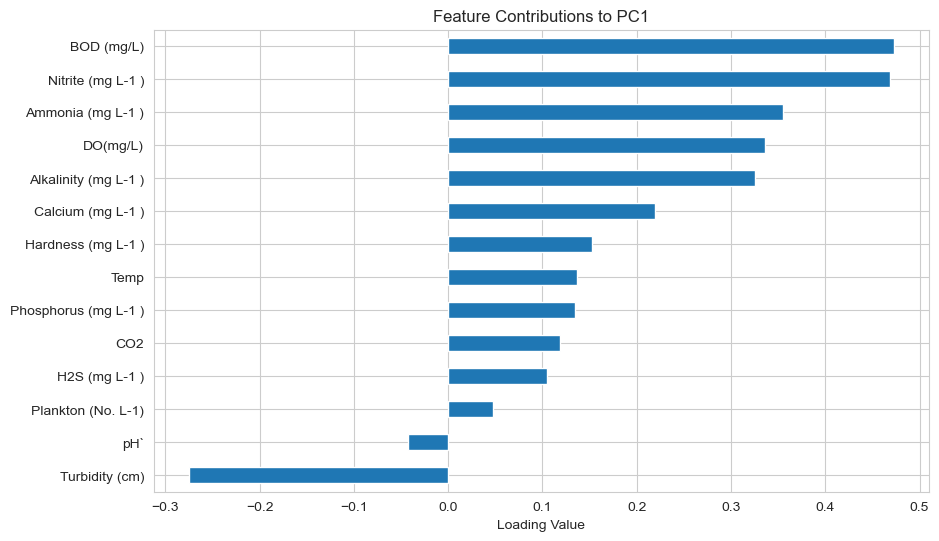

In [39]:
plt.figure(figsize=(10,6))
loadings['PC1'].sort_values().plot(kind='barh')
plt.title("Feature Contributions to PC1")
plt.xlabel("Loading Value")
plt.show()


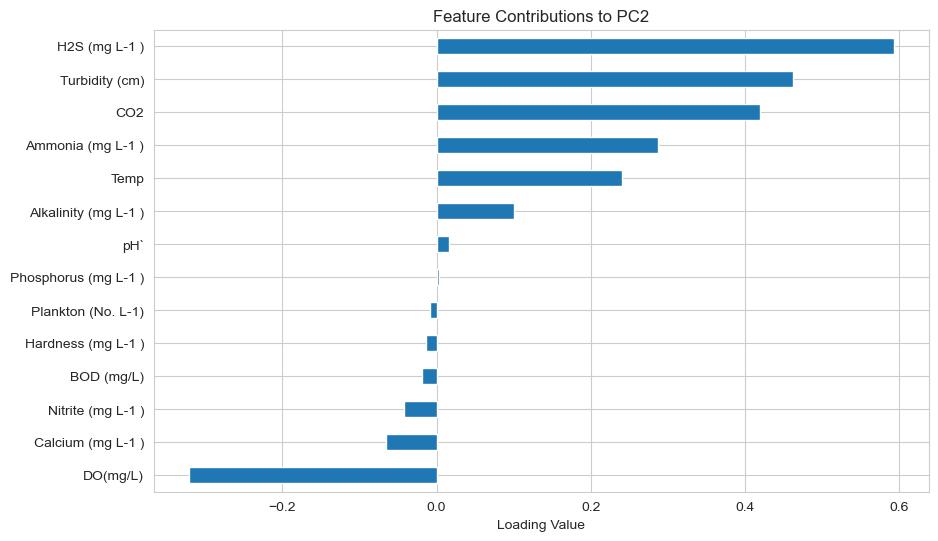

In [40]:
plt.figure(figsize=(10,6))
loadings['PC2'].sort_values().plot(kind='barh')
plt.title("Feature Contributions to PC2")
plt.xlabel("Loading Value")
plt.show()
